In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append("..")

In [ ]:
import torch
import torch.fft
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import numpy as np

import time

import random

import soap
from architectures import PINO1D
from generators import SlabWaveguideDataset
from utils import analytical_solution, solve_fd_mode

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [47]:
def evaluate_model_errors(model, dataset, device):
    field_errors_pino = []
    field_errors_fd = []
    eigenvalue_errors_pino = []
    eigenvalue_errors_fd = []

    model.eval()
    for idx in range(len(dataset)):
        xyr, features = dataset[idx]
        xyr = xyr.unsqueeze(0).to(device)
        features = features.unsqueeze(0).to(device)
        dx = dataset.dx

        k0 = features[0, 0].item()
        TE = features[0, -1].item()
        n2_max = features[0, -2]
        n2_min = torch.minimum(features[0, -4], features[0, -3])

        with torch.no_grad():
            E_out, beta_nn = model(xyr)
        E_out = E_out.squeeze().cpu().numpy()
        x_out = xyr[:, 0, :].squeeze().cpu().numpy()
        ri_out = xyr[:, 1, :].squeeze().cpu().numpy()

        beta_sq = (n2_max - beta_nn * (n2_max - n2_min)) * k0**2
        beta_pino = torch.sqrt(beta_sq).item()

        # Solve FD
        beta_fd, modes_fd = solve_fd_mode(ri_out, dx, k0, TM=(TE == 0), num_modes=1)
        mode_fd = modes_fd[0]

        # Analytical
        n_clad = torch.sqrt(features[0, -4]).item()
        n_subs = torch.sqrt(features[0, -3]).item()
        n_core = torch.sqrt(features[0, -2]).item()
        w_core = features[0, 1].item()
        analytical_modes, analytical_EIs = analytical_solution(x_out, n_core, n_subs, n_clad, w_core, k0, TE==0)
        mode_ana = analytical_modes[0]
        beta_ana = analytical_EIs[0] * k0

        # Normalize fields
        E_out /= np.linalg.norm(E_out)
        mode_fd /= np.linalg.norm(mode_fd)
        if TE == 0:
            mode_ana = mode_ana / ri_out
        mode_ana /= np.linalg.norm(mode_ana)

        # Fix signs
        sign_pino = np.sign(np.dot(E_out, mode_ana))
        sign_fd = np.sign(np.dot(mode_fd, mode_ana))
        E_out *= sign_pino
        mode_fd *= sign_fd

        # Errors
        err_pino = 100 * np.linalg.norm(E_out - mode_ana) / np.linalg.norm(mode_ana)
        err_fd = 100 * np.linalg.norm(mode_fd - mode_ana) / np.linalg.norm(mode_ana)
        
        field_errors_pino.append(err_pino)
        field_errors_fd.append(err_fd)

        eigenvalue_errors_pino.append(np.abs((beta_pino - beta_ana) / beta_ana))
        eigenvalue_errors_fd.append(np.abs((beta_fd - beta_ana) / beta_ana))

    # Number of samples
    N = len(field_errors_pino)
    
    # -----------------------------
    # Means
    # -----------------------------
    field_error_pino_mean = np.mean(field_errors_pino)
    field_error_fd_mean = np.mean(field_errors_fd)
    
    eigen_error_pino_mean = np.mean(eigenvalue_errors_pino)
    eigen_error_fd_mean = np.mean(eigenvalue_errors_fd)
    
    # -----------------------------
    # Standard deviations
    # -----------------------------
    field_error_pino_std = np.std(field_errors_pino, ddof=1)
    field_error_fd_std = np.std(field_errors_fd, ddof=1)
    
    eigen_error_pino_std = np.std(eigenvalue_errors_pino, ddof=1)
    eigen_error_fd_std = np.std(eigenvalue_errors_fd, ddof=1)
    
    # -----------------------------
    # Standard errors
    # -----------------------------
    field_error_pino_sem = field_error_pino_std / np.sqrt(N)
    field_error_fd_sem = field_error_fd_std / np.sqrt(N)
    
    eigen_error_pino_sem = eigen_error_pino_std / np.sqrt(N)
    eigen_error_fd_sem = eigen_error_fd_std / np.sqrt(N)
    
    # -----------------------------
    # 95% confidence intervals
    # -----------------------------
    z = 1.96
    
    field_error_pino_ci = z * field_error_pino_sem
    field_error_fd_ci = z * field_error_fd_sem
    
    eigen_error_pino_ci = z * eigen_error_pino_sem
    eigen_error_fd_ci = z * eigen_error_fd_sem
        
    return {
    
        'field_errors_pino': field_errors_pino,
        'field_errors_fd': field_errors_fd,
        'eigenvalue_errors_pino': eigenvalue_errors_pino,
        'eigenvalue_errors_fd': eigenvalue_errors_fd,
    
        # Means
        "field_error_pino": field_error_pino_mean,
        "field_error_fd": field_error_fd_mean,
        "eigen_error_pino": eigen_error_pino_mean,
        "eigen_error_fd": eigen_error_fd_mean,
    
        # Standard deviations
        "field_error_pino_std": field_error_pino_std,
        "field_error_fd_std": field_error_fd_std,
        "eigen_error_pino_std": eigen_error_pino_std,
        "eigen_error_fd_std": eigen_error_fd_std,
    
        # 95% confidence intervals
        "field_error_pino_ci95": field_error_pino_ci,
        "field_error_fd_ci95": field_error_fd_ci,
        "eigen_error_pino_ci95": eigen_error_pino_ci,
        "eigen_error_fd_ci95": eigen_error_fd_ci,
    }

In [10]:
def collect_features(dataset, n_samples):
    loader = DataLoader(dataset, batch_size=n_samples, shuffle=True)
    feat = next(iter(loader))[1]
    feat[..., 0] = 2 * np.pi / feat[..., 0]
    feat[..., 2:5] = torch.sqrt(feat[..., 2:5])
    return feat

train_dataset = SlabWaveguideDataset(n_dataset=640000, stochastic=True, device='cpu')
test_dataset = SlabWaveguideDataset(n_dataset=1024, device='cpu')

torch.manual_seed(42)
test_features  = collect_features(test_dataset, 1000)
train_features = collect_features(train_dataset, 640000)
train_features_0 = collect_features(train_dataset, 500)
train_features_1 = collect_features(train_dataset, 10000)

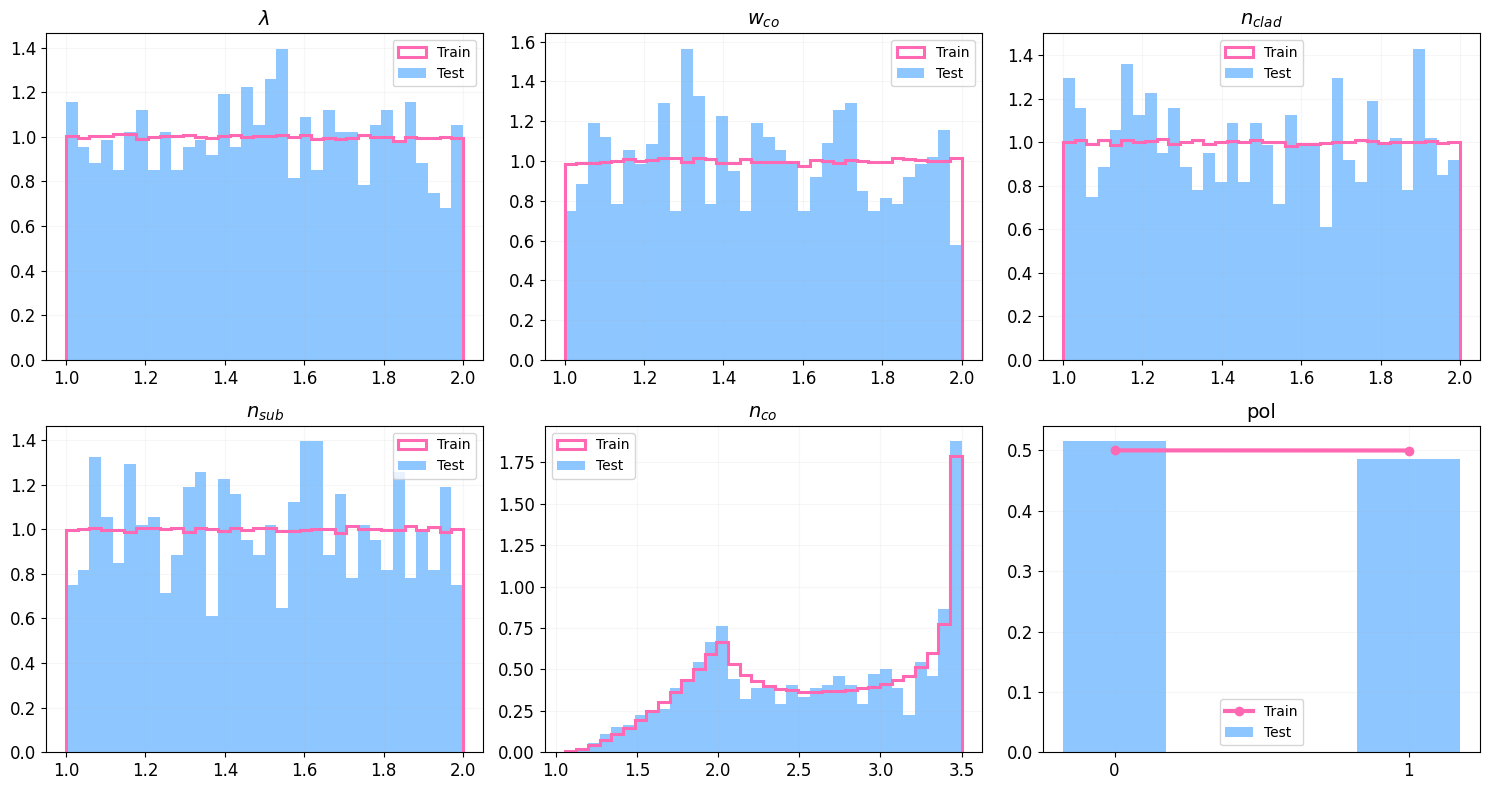

In [11]:
feature_names = [
    "$\lambda$",
    "$w_{co}$",
    "$n_{clad}$",
    "$n_{sub}$",
    "$n_{co}$",
    "pol"
]

num_features = len(feature_names)
cols = 3
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_features):
    ax = axes[i]
    
    if feature_names[i] == "pol":
        x = [0, 1]
        train_probs = [
            torch.mean((train_features[:, i] == 0).to(float)),
            torch.mean((train_features[:, i] == 1).to(float))
        ]
        test_probs = [
            torch.mean((test_features[:, i] == 0).to(float)),
            torch.mean((test_features[:, i] == 1).to(float)),
        ]
        ax.plot(
            x,
            train_probs,
            color='#FF69B4',
            linewidth=3,
            marker='o',
            label='Train'
        )
        ax.bar(
            x,
            test_probs,
            alpha=0.5,
            color='#1E90FF',
            width=0.35,
            label='Test'
        )
        ax.set_xticks([0, 1])

    else:

        all_vals = np.concatenate([
            train_features[:, i],
            test_features[:, i]
        ])

        bins = np.linspace(all_vals.min(), all_vals.max(), 35)
        ax.hist(
            train_features[:, i].float(),
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2.2,
            color='#FF69B4',
            label='Train'
        )
        ax.hist(
            test_features[:, i].float(),
            bins=bins,
            density=True,
            alpha=0.5,
            color='#1E90FF',
            linewidth=0.4,
            label='Test'
        )

    ax.set_title(feature_names[i], fontsize=14)
    ax.grid(alpha=0.1)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.legend()
    ax.set_facecolor('white')
    
fig.patch.set_facecolor('white')

for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

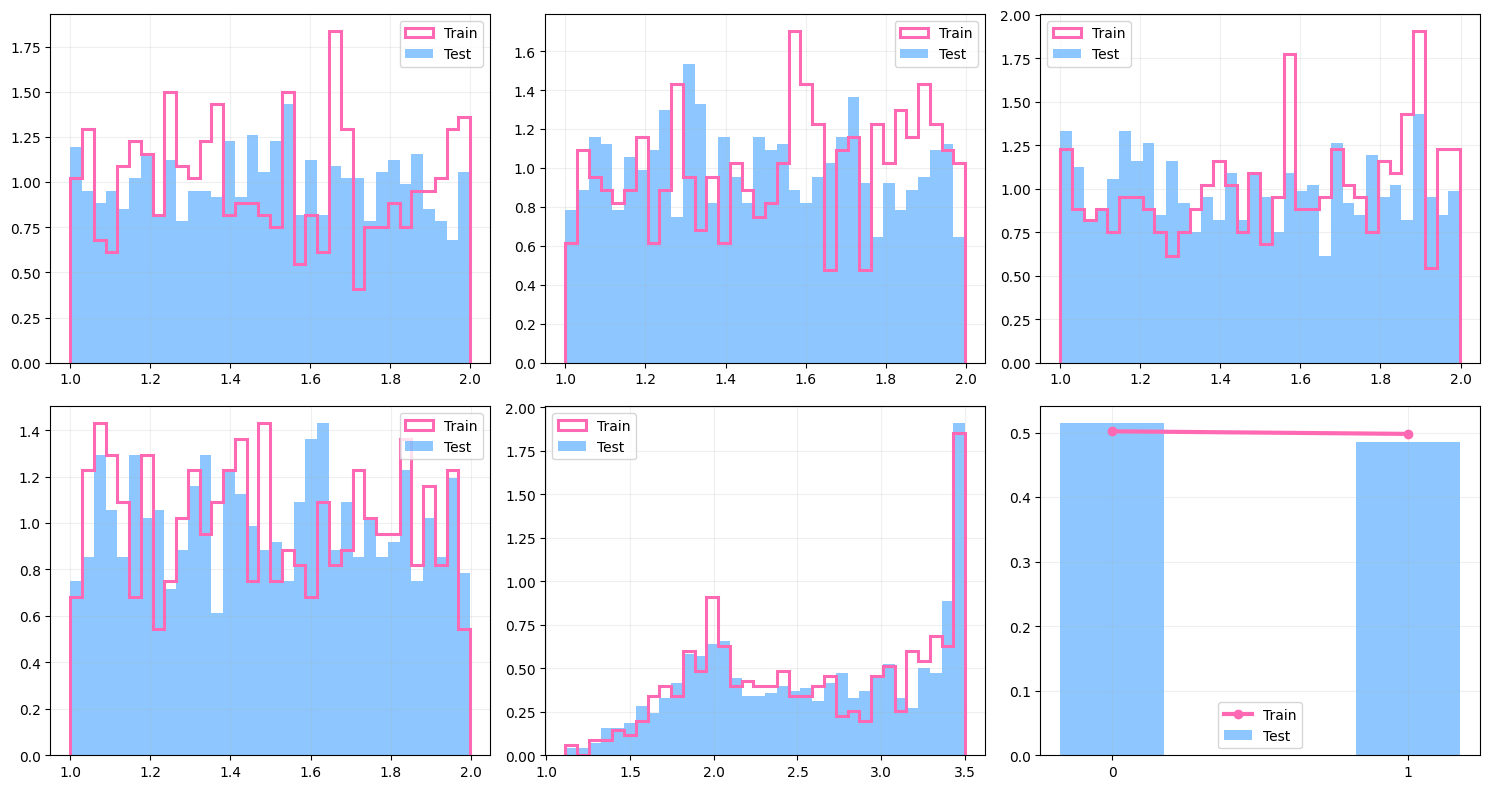

In [12]:
num_features = len(feature_names)
cols = 3
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_features):

    ax = axes[i]

    # -----------------------------
    # Binary TE flag
    # -----------------------------
    if feature_names[i] == "pol":

        x = [0, 1]

        train_probs = [
            torch.mean((train_features_0[:, i] == 0).to(float)),
            torch.mean((train_features_0[:, i] == 1).to(float))
        ]

        test_probs = [
            torch.mean((test_features[:, i] == 0).to(float)),
            torch.mean((test_features[:, i] == 1).to(float)),
        ]

        ax.plot(
            x,
            train_probs,
            color='#FF69B4',
            linewidth=3,
            marker='o',
            label='Train'
        )

        ax.bar(
            x,
            test_probs,
            alpha=0.5,
            color='#1E90FF',
            width=0.35,
            label='Test'
        )

        ax.set_xticks([0, 1])

    # -----------------------------
    # Continuous parameters
    # -----------------------------
    else:

        all_vals = np.concatenate([
            train_features_0[:, i],
            test_features[:, i]
        ])

        bins = np.linspace(all_vals.min(), all_vals.max(), 35)

        # Train: outline only
        ax.hist(
            train_features_0[:, i].float(),
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2.2,
            color='#FF69B4',
            label='Train'
        )

        # Test: filled histogram
        ax.hist(
            test_features[:, i].float(),
            bins=bins,
            density=True,
            alpha=0.5,
            color='#1E90FF',
            linewidth=0.4,
            label='Test'
        )

    # ax.set_title(feature_names[i], fontsize=11)

    ax.grid(alpha=0.2)

    ax.legend()

# Remove unused axes
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

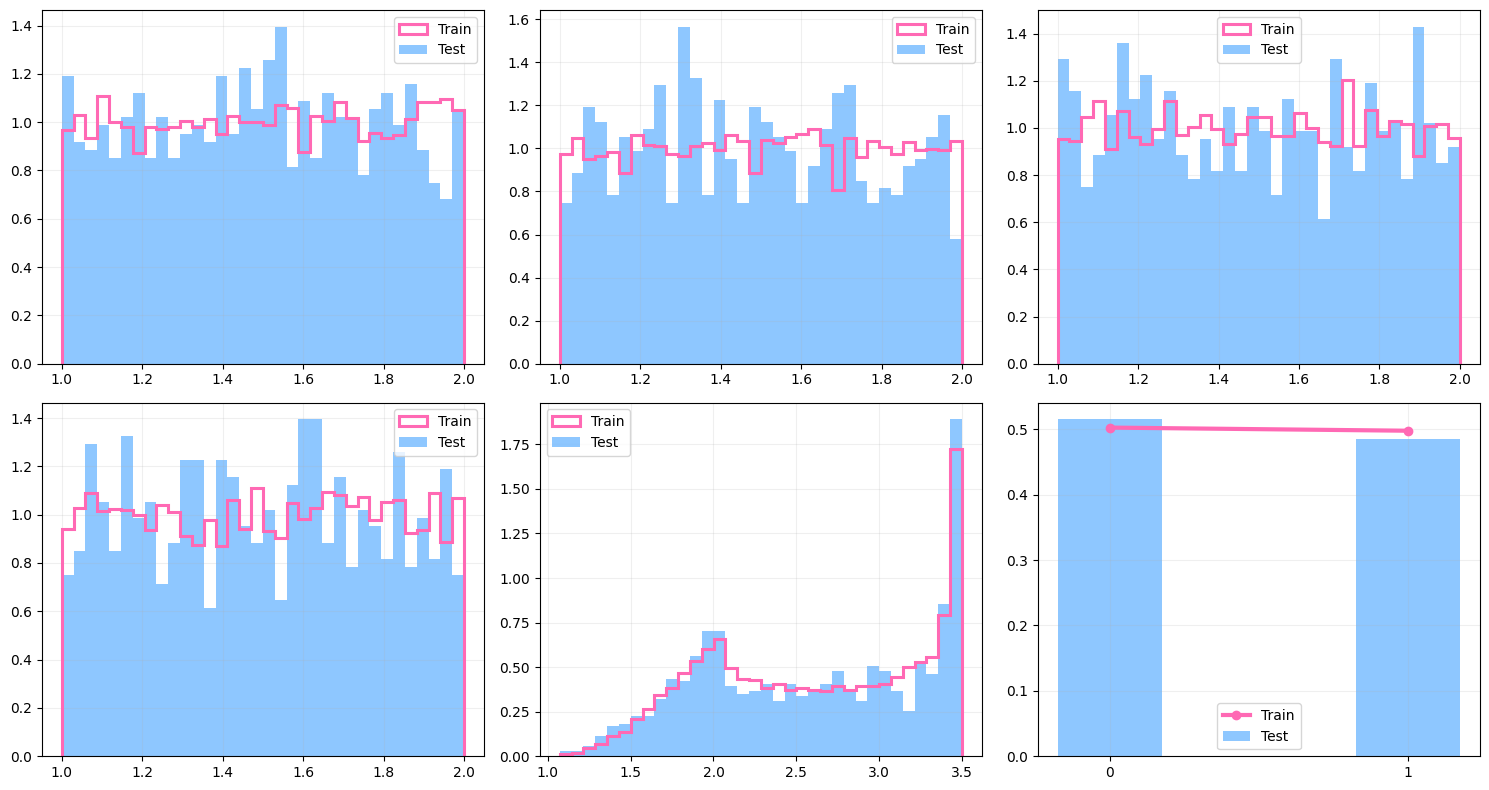

In [13]:
num_features = len(feature_names)
cols = 3
rows = int(np.ceil(num_features / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i in range(num_features):

    ax = axes[i]

    # -----------------------------
    # Binary TE flag
    # -----------------------------
    if feature_names[i] == "pol":

        x = [0, 1]

        train_probs = [
            torch.mean((train_features_1[:, i] == 0).to(float)),
            torch.mean((train_features_1[:, i] == 1).to(float))
        ]

        test_probs = [
            torch.mean((test_features[:, i] == 0).to(float)),
            torch.mean((test_features[:, i] == 1).to(float)),
        ]

        ax.plot(
            x,
            train_probs,
            color='#FF69B4',
            linewidth=3,
            marker='o',
            label='Train'
        )

        ax.bar(
            x,
            test_probs,
            alpha=0.5,
            color='#1E90FF',
            width=0.35,
            label='Test'
        )

        ax.set_xticks([0, 1])

    # -----------------------------
    # Continuous parameters
    # -----------------------------
    else:

        all_vals = np.concatenate([
            train_features_1[:, i],
            test_features[:, i]
        ])

        bins = np.linspace(all_vals.min(), all_vals.max(), 35)

        # Train: outline only
        ax.hist(
            train_features_1[:, i].float(),
            bins=bins,
            density=True,
            histtype='step',
            linewidth=2.2,
            color='#FF69B4',
            label='Train'
        )

        # Test: filled histogram
        ax.hist(
            test_features[:, i].float(),
            bins=bins,
            density=True,
            alpha=0.5,
            color='#1E90FF',
            linewidth=0.4,
            label='Test'
        )

    # ax.set_title(feature_names[i], fontsize=11)

    ax.grid(alpha=0.2)

    ax.legend()

# Remove unused axes
for i in range(num_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Epoch 249:
  β² prediction ≈ [197.4797   142.18385  275.85403  101.87073   29.654177  69.9863
 131.37932  111.451614  70.33215  121.03505  109.78797  207.87836
  82.76408  131.75981   79.436646 291.4916   120.138504  73.02417
 412.43982  103.13266  304.4045   299.96613  271.44666   30.439234
 266.9553   217.89653   76.100784 153.06006   68.64359  128.69565
 397.4287   125.055725 119.0007   316.99774  308.04926  339.73343
 121.45148   91.12612   66.40138   58.579136 128.93547   70.31266
  78.38702  344.11816   98.138824 249.7562   140.73798  113.424934
  66.96835  361.81284  179.56018   70.26036 ]
  β² max ≈ [197.4797   142.18385  275.85403  101.87073   29.654182  69.9863
 131.37932  111.451614  70.33215  121.03505  109.78797  207.87836
  82.76408  131.75981   79.436646 291.4916   120.138504  73.02417
 412.43982  103.13266  304.4045   299.96613  271.44666   30.439234
 266.9553   217.89653   76.100784 153.06006   68.64359  128.69565
 397.4287   125.055725 119.0007   316.99774  308.04926 

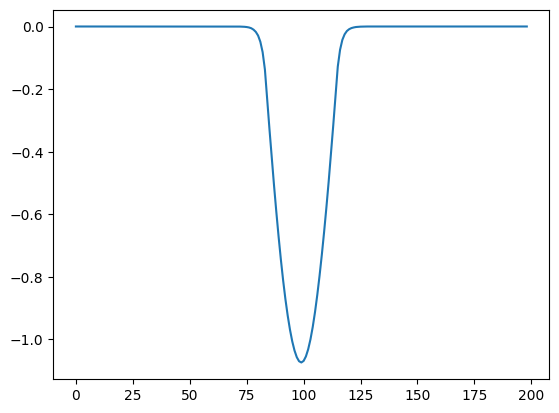

Epoch 1249:
  β² prediction ≈ [260.20016  104.23542   68.11351  124.492195  39.53661  166.99496
 202.53621  129.26697  235.39954  154.4742    22.194828 248.03851
  99.121925 175.57118  116.542755  23.91122  206.65038  148.1037
  27.282291 152.63724   85.79221   78.716835  35.935314  56.560574
  58.24724   17.058153 321.4629    26.178774  86.59149   42.849762
 101.22022   93.09314   60.676266 122.8551   110.09457  115.12223
 252.53786  255.52432  154.92464  185.30174   75.27367  324.67477
 183.36276  120.857056  70.27664   68.1264    21.623844 120.26949
 340.05753   43.15744  238.40361   48.122063]
  β² max ≈ [265.28403  109.23971   72.46701  128.73448   40.961014 170.57738
 208.03308  131.83514  241.32669  157.53424   23.580332 251.25514
 101.52104  182.10503  123.278114  26.183672 213.32104  152.011
  29.654182 156.16364   88.80801   82.40487   38.84078   58.64524
  61.562305  18.704117 326.71912   27.461876  88.12129   44.498493
 105.05909   95.545586  63.487404 129.53099  113.424934

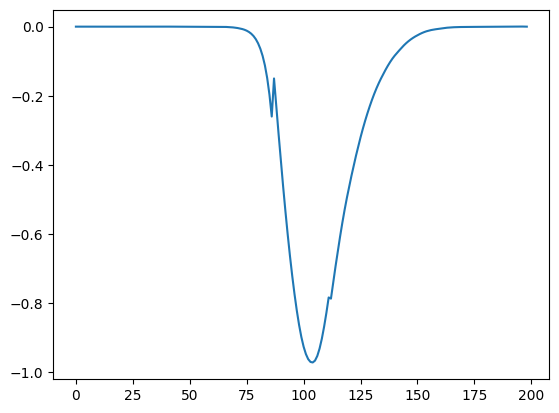

Epoch 2249:
  β² prediction ≈ [108.6166   101.004684 339.80145  322.62326   70.420296  60.56804
 124.187515 134.01828   60.408154  67.0555    69.66728   22.24035
  23.485357  92.86111  105.20572  105.18523  114.60482  135.1323
  86.950554 115.22153  341.74295  167.02518   22.12724  138.88193
 327.73032  122.282196 313.9729   148.17221   74.8215   228.02138
 117.34908  257.0213    41.63518  124.669334 101.090416 252.92873
 116.65782   65.66638   75.85284  122.86153   45.735497  56.424442
 222.41064  297.46237  150.42467  173.70712  258.64282   83.38963
 230.417     98.62095  142.82623   75.613304]
  β² max ≈ [112.19306  104.30384  345.95947  325.8617    75.393005  63.487404
 128.73448  137.64752   64.44676   70.33215   72.06363   23.402536
  24.674953  95.11084  108.34452  109.78797  118.50447  137.32497
  90.36414  119.62038  344.11816  170.57738   23.580332 141.75836
 330.6602   125.08288  317.12607  152.011     78.15563  231.08191
 123.0576   264.1141    44.574913 127.037125 104.8921

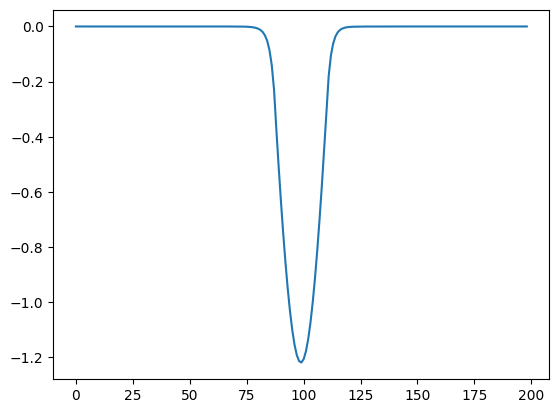

Epoch 3249:
  β² prediction ≈ [325.98645   47.104862 352.9857    65.767265 368.70575  442.3759
  44.014854 133.2976    79.72632  234.99213  342.60178  198.75809
 117.85577   52.070034 124.7543    24.49638   83.91839   85.76591
 287.28018  197.58524  104.29901  194.21277  101.125725  44.454872
 128.16809   59.65392   49.041973 181.57057  135.40979  104.1974
  29.834335  53.31072   34.517345 122.66489   78.972824 297.15097
  49.589684 112.638115 125.89966  241.08244   74.02977  174.66637
  17.084337 218.99095  105.332054 237.3169    70.22374  287.52225
 261.45303  122.35978  393.43564  130.42157 ]
  β² max ≈ [333.0959    49.73492  355.4658    69.031425 373.26624  445.13113
  46.968636 137.72534   83.998886 237.36624  346.5031   204.57158
 125.055725  56.168224 129.49942   25.857769  86.867874  88.80801
 290.67484  200.5362   107.34384  197.4797   104.30384   46.068363
 130.3085    62.33099   52.194202 184.22331  138.072    109.23971
  31.130686  55.114594  38.57068  128.69565   84.69236 

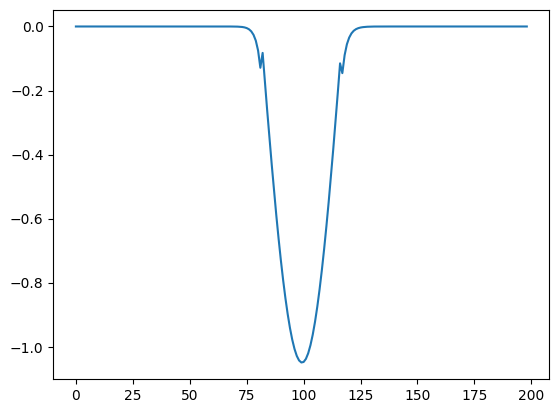

Epoch 4249:
  β² prediction ≈ [ 50.87824  114.93077   66.303665  98.950714  49.052383  67.14223
 235.41312   60.91268   43.823353  48.60366  110.07715   61.20437
  69.76788  111.537155  33.977867 228.14615   41.69888  203.77605
  53.244736  17.204966 255.21501  314.0412   124.31194  164.31493
 130.52156   78.69575  105.30975  293.62      82.52427  112.84668
 142.79933  167.27196  123.06534  152.1381   212.39388  146.70148
  64.0888   320.81747  137.327    164.07938   38.153442  74.95958
 168.29845   32.03459  106.334885 297.60645   31.332558 252.58212
  75.62113   76.00565  297.19894   57.20367 ]
  β² max ≈ [ 54.089066 117.25535   68.57365  100.87386   52.194202  70.33215
 241.32669   63.724     46.53173   53.94383  112.33095   63.004715
  72.06363  114.028366  37.8801   231.08191   44.574913 208.63828
  55.114594  18.704117 258.24066  317.12607  127.70482  170.1825
 134.8149    82.40487  108.174706 297.99762   84.564125 116.19657
 145.36777  171.18073  129.53099  156.02608  215.92943 

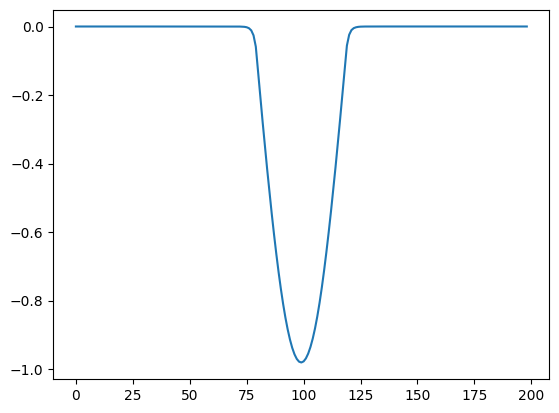

Epoch 5249:
  β² prediction ≈ [124.721954 202.06773   34.251694 152.71709  368.71005  222.37231
  44.331287 120.31234  167.2986   127.81448  140.00125   51.10114
 134.14514  269.2531    21.50439  255.55022  150.49243  108.73581
 137.30057  115.9621    60.647778 167.78781  314.04156   43.0186
  76.805084 339.1012   109.289764  79.47128  341.84955  381.50568
  76.37821  106.45225  248.15463  184.51227   84.71303   49.328968
 112.78114   65.27917  235.41193  121.77389  175.91574   89.36622
 115.07933  206.63972  148.40894  470.9625    79.79382   94.1984
 292.41132  419.84326  186.44112   83.46669 ]
  β² max ≈ [127.037125 205.54016   36.968773 156.16364  373.26624  226.08527
  45.886333 125.239204 171.52324  130.4074   142.75328   57.602898
 137.64752  274.33478   23.186802 258.2249   154.16432  112.19306
 142.18385  124.29772   63.487404 170.29416  317.12607   44.498493
  79.04764  343.06796  114.08154   82.98334  344.11816  384.06287
  78.33914  110.65393  251.25514  188.29369   87.58648

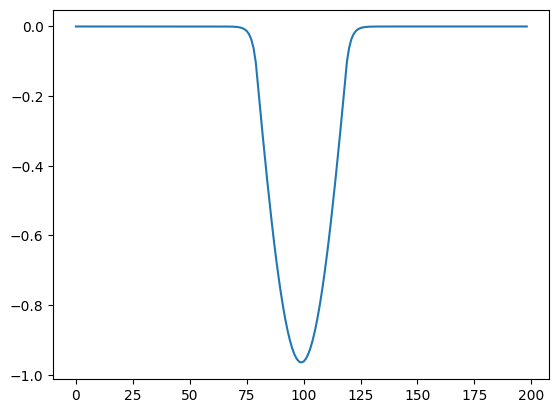

Epoch 6249:
  β² prediction ≈ [116.68674  212.38666  183.32458   73.18342  186.43571   95.95698
 221.36847  297.5919   322.71497   91.88965  419.8339   260.21616
  86.25135  159.49858  243.42653  110.07743  138.23282   92.52674
  76.3646    47.048428  74.21935  164.70569   97.38475   60.95791
  78.67752  121.67056  203.88895   98.01751  181.57661  168.26256
  54.98058  116.136566 360.35788   44.32223   55.075386 272.9226
 101.13947  104.262085  18.61608   59.72315   98.036964 124.71911
  69.75838   35.877274  72.83011  115.16781  130.03088  142.71094
 368.7166   167.30388  146.22568  273.38025 ]
  β² max ≈ [119.2684   215.92943  188.99402   76.35981  189.92969   98.138824
 224.14761  303.45453  325.8617    93.935394 422.38806  265.28403
  89.0457   165.2696   248.66068  118.27773  140.36285   97.61673
  78.33914   49.73492   75.86549  167.37077  102.38485   63.724
  82.40487  124.169044 210.8883   103.8082   184.22331  171.13362
  57.251125 118.60961  367.45197   45.886333  58.579136 2

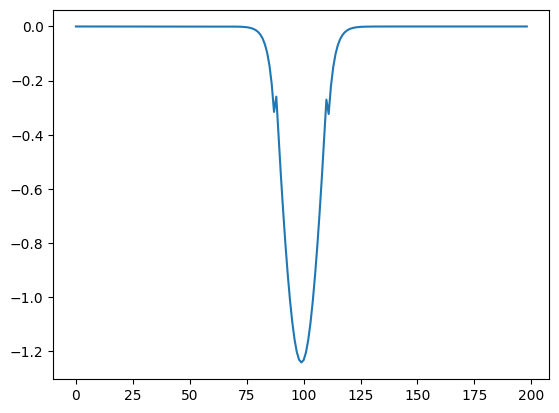

Epoch 7249:
  β² prediction ≈ [122.300285 115.52911   21.074884 118.84788   79.19296   80.68199
 106.74456  241.16109   24.466612 138.22949  154.50761  169.1538
 284.53607   95.52166  375.91925  135.68918  143.14232   98.88111
  17.246876 237.30911   52.06352   75.51769  242.56464   82.51065
 105.372894 143.43279   59.650032 137.65538   90.05475   66.22425
 292.41632   31.277676 202.76027  116.39763  124.29495   44.294216
  41.645874 130.85387   64.11938  165.37767  197.7979    74.11163
 114.80189  189.55502  110.04817  253.98375  121.74322  116.131874
 164.97395   47.402523  91.88485  279.05103 ]
  β² max ≈ [125.08288  120.8754    22.556864 121.45148   84.257     83.90187
 110.614746 249.45828   25.857769 140.36285  157.53424  172.10678
 289.69113   99.41892  379.06055  138.94653  146.98085  100.87386
  18.704117 240.06642   56.168224  78.38702  250.93634   84.564125
 108.174706 145.55989   62.33099  143.20952   95.6341    68.57365
 294.90454   33.27125  208.99821  121.03505  127.8919

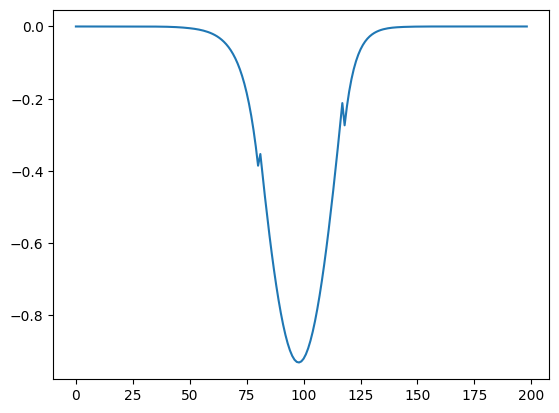

Epoch 8249:
  β² prediction ≈ [ 44.415073 241.18794   79.47361  212.39818  248.15004   58.626225
  86.57518   37.440037 258.7021    47.03618  272.9339   101.05437
  80.827    148.41609  104.23289   95.95692   52.142033 129.4666
  70.19656  142.11682  112.65722   90.064415  63.559113 258.59717
  38.562473 235.4136    98.012634 322.71823  390.28894  131.02185
 140.5697   197.60274  124.8151   105.28579  105.37407  105.27442
  77.97819   86.249565  57.597095  75.71669  111.106346 272.4849
  71.83019   52.08945   67.13223  132.28047  136.35684  167.14049
 241.29471   43.061848 279.0633   405.31372 ]
  β² max ≈ [ 46.091675 249.45828   82.98334  215.92943  251.25514   61.23073
  89.42781   40.283337 263.7282    49.73492  278.21347  104.30384
  84.87128  151.5402   109.23971   98.138824  55.016537 134.89816
  72.502464 146.71727  115.15041   95.6341    66.68703  260.84253
  44.016685 241.32669  103.8082   325.8617   397.4287   133.34984
 143.36601  204.19995  129.49942  109.78797  108.174706 

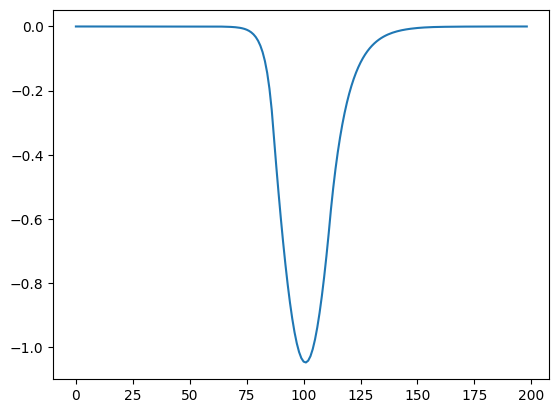

Epoch 9249:
  β² prediction ≈ [ 76.23403   34.238228  64.220535  65.26373  120.75427   14.198805
  39.984734 116.13239  130.47803   49.009052 132.2749    19.52646
  70.194626  68.87802  243.42947  413.05493  121.67142   85.58842
  50.875397 128.14801   86.89872  238.42868   26.229492  84.90399
 117.91355   68.003685 214.5349    59.29099   51.0966   327.84644
 352.9341   140.56798  121.76178   21.078588 122.619484 203.74701
  67.065674  37.11928  104.26333  175.91273  135.69771  127.81704
 101.14227  399.5377    21.504932 116.584175  47.81738  244.64522
  89.01926   77.99281   47.409336 159.5066  ]
  β² max ≈ [ 80.42033   36.968773  66.96835   68.64359  126.098694  15.574093
  43.118717 118.60961  134.8149    52.194202 134.62128   20.597492
  72.502464  70.29944  248.66068  415.8642   124.169044  88.227196
  54.089066 130.3085    89.49177  240.6637    27.461876  88.35904
 125.055725  73.02417  218.33318   64.34594   57.602898 330.6602
 355.4658   143.36601  127.84229   22.556864 128.695

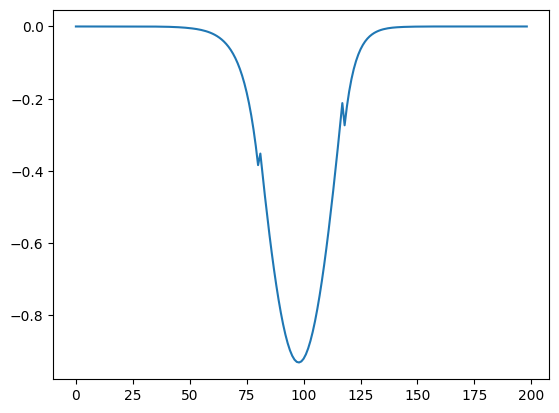

Epoch 249:
  β² prediction ≈ [122.224686 129.78766   42.073273 124.32324  175.17918   43.228146
 291.9553    88.62209   95.46803   49.89509  318.7775   209.1683
 334.43124  225.9415   128.2364   311.79327   70.99975   90.42416
 207.1507    26.461102 118.71425  149.21669   25.084173  67.13922
  57.784622 182.27144  109.605965 207.5429    74.075516  77.096436
  57.827606 320.1253   127.74298   44.77462  135.84052  157.28152
 147.23653   46.83376  124.6634    99.73908  294.5813    75.395325
 239.86584  109.18456   63.643562  29.605906 125.16859   85.1849
 108.72253  148.84665  214.1251    43.87167  128.6404    95.02768
  60.534344  56.65604   68.44327   79.025635  58.2804    67.34062
 103.19967   61.67879  219.5007    57.71726 ]
  β² max ≈ [122.224686 129.78766   42.073273 124.32324  175.17918   43.228153
 291.9553    88.62209   95.46803   49.89509  318.7775   209.1683
 334.43124  225.9415   128.2364   311.79327   70.99975   90.42416
 207.1507    26.461102 118.71425  149.21669   25.084173

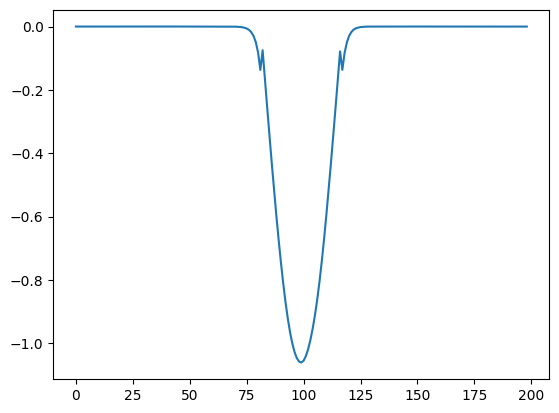

Epoch 1249:
  β² prediction ≈ [135.9769    96.77555   78.062645  81.293526 385.43326  117.80986
  30.113342  47.34428  113.10194   93.86468  342.53293  201.5226
 129.15862   38.054337 261.4097    40.190525  22.953262 108.582634
  38.4048    65.17204   43.61498  105.176765  52.21748   80.10551
  81.27529  289.41608   50.53727  276.0871    72.440414  36.969032
 157.13779  188.2332   130.21797  146.36865  223.33598  108.72058
 209.31934   60.753384 253.43584  129.3946  ]
  β² max ≈ [142.45425  100.36962   83.70105   82.97871  391.74893  120.05675
  31.510143  53.066483 118.430374  97.125626 345.1733   204.777
 135.43774   39.59602  264.15234   44.73135   25.084173 111.21949
  41.897457  69.974495  45.15109  110.358315  53.63355   85.655014
  83.298416 294.5813    56.232212 283.68964   74.40409   38.6363
 161.16245  195.27173  131.9548   150.06694  225.70331  111.48208
 214.45595   62.96266  260.3483   132.76753 ]
Physics Loss: 6.190755e-02  Total Loss: 6.190822e-02
Epoch 1499:
  β² predic

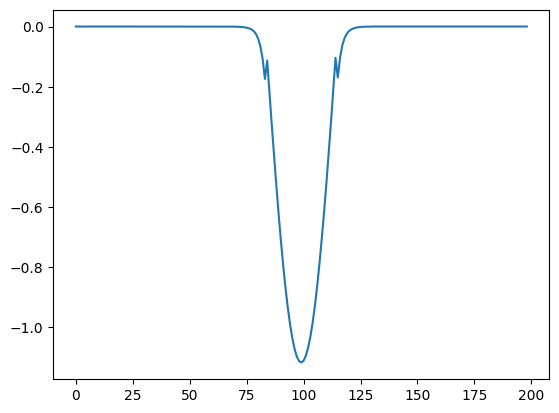

Epoch 2249:
  β² prediction ≈ [ 58.883045 164.03342   55.914764  75.876076  62.73786   31.882597
 211.63942  172.23074   88.412025 229.31139  204.8704    55.145733
  26.732525  46.497158 173.82759   21.676786 130.93745  115.502144
 311.2628   143.75235  155.28925  231.36096  142.94205  234.45706
 216.03445  105.93521  478.31497   99.769394  70.48106  432.8311
 108.80937   69.904434 165.52672   53.762047 106.22381  133.18379
 159.7993   302.14255  219.25978  160.73103  204.63057   81.46995
 122.36755  100.70744   67.44274  156.26259  260.59995  166.70287
 384.07727   96.13026  118.82533   78.752525  96.15538  152.55171
 210.7174    44.942104  64.27806  175.85889  126.25848  102.72225
 111.55409  109.69915  307.4519    40.139194]
  β² max ≈ [ 64.19795  166.27107   59.339733  79.28234   68.08969   33.21914
 215.64447  174.46144   90.42416  232.07816  207.1507    56.820827
  28.319569  48.494183 179.53886   23.39022  133.76968  120.61592
 317.1263   146.29138  158.478    233.83365  146.615

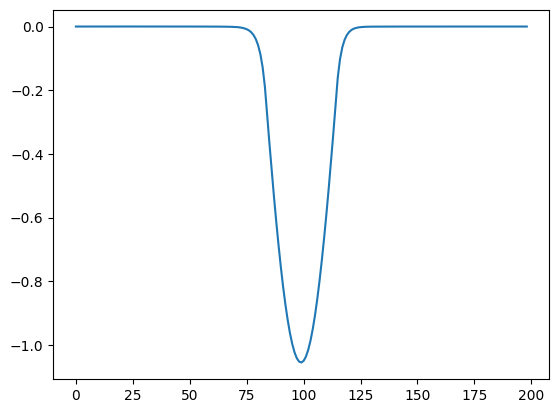

Epoch 3249:
  β² prediction ≈ [ 78.67077   91.63368  236.79205   97.71816  150.00824  146.81026
 219.97519   79.82639   64.67942  127.83796  240.12076   38.97195
 226.77933  108.96514  222.8444   137.57204  271.85254  285.82068
  86.64258  225.30597  377.0197    97.59073  283.77084  176.40402
  42.319843  47.398014 121.08174  276.5804    46.520878 102.409874
  59.04343   46.816364  96.86517  174.07051  146.25209  169.71599
  56.169365 171.3305   228.68326   25.650448]
  β² max ≈ [ 82.87824   93.41344  239.86584  101.21452  157.28152  154.91484
 222.73291   82.490944  66.7752   130.18648  245.23372   43.228153
 230.31424  112.931496 225.9415   142.33698  274.64557  291.9553
  89.515305 228.76793  383.18155  103.31662  286.62555  180.20473
  43.87167   49.006866 125.5677   283.68964   49.463028 106.2684
  61.67879   48.80203  102.65941  177.53809  150.60503  174.44202
  57.607567 173.52928  235.58011   28.934074]
Physics Loss: 1.356813e-02  Total Loss: 1.356823e-02
Epoch 3499:
  β² predi

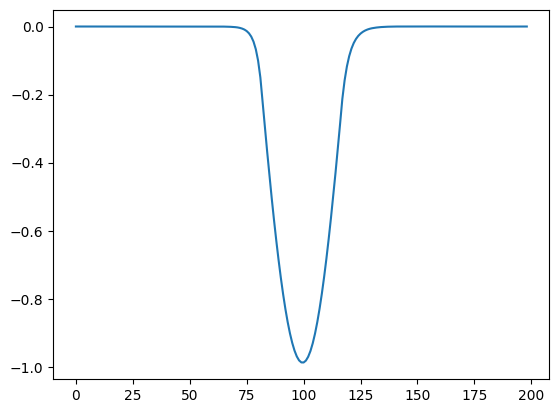

Epoch 4249:
  β² prediction ≈ [105.63033   96.625206  37.429543 201.67644  145.0341   478.3525
  70.39081  446.683    155.27444  153.95836   80.7771   138.47923
 169.73502  114.277504  45.677345 419.70926  136.81062   96.640274
 119.375786 116.27637  204.7296    50.841976 285.05182  137.64398
  40.27736  129.05367  203.35645  131.23552  182.9668    60.791073
 217.74449   54.488228  38.994576  70.12724  134.1012   203.83707
  52.86583   55.144188  81.11857   47.241665 174.14204  314.17563
 176.35086  310.4269    44.25255  127.14119  172.75168  226.49968
 104.52495  103.290855 107.95949  126.97806  157.95674  229.73654
 136.28574   36.513622  80.21551  234.51479   40.116356  29.458279
  82.46115  323.15384   81.39915  122.44695 ]
  β² max ≈ [107.60044   98.90982   38.99944  204.777    148.14711  480.91043
  73.1652   451.78342  158.478    158.61827   82.5851   142.11433
 172.0689   116.38395   50.047035 423.65698  138.99742  100.36962
 122.55086  119.46361  207.57262   55.45765  288.8776

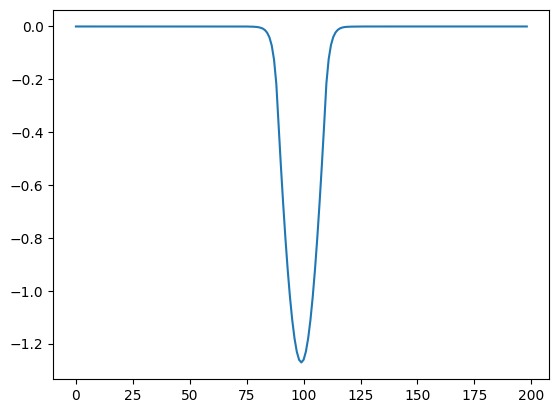

Epoch 5249:
  β² prediction ≈ [407.39633  132.01558  126.89536  120.372116 188.07613  157.85446
 159.72356  285.00385  133.43918   45.40705  107.39686   97.72526
  54.215385  98.36149   74.32615  126.352745  63.379288 192.53311
 175.92894  111.22077   23.171328 181.66579  323.1899    43.406483
 109.70231  169.82953  104.54528  309.21957  271.91565  148.95149
 152.71063  240.6436   378.84836  427.1365    52.241074  60.97398
 105.408424 203.81184  127.90794  165.16783 ]
  β² max ≈ [413.4411   135.68724  134.78128  125.44567  190.7926   166.42563
 162.86104  288.87762  137.51433   47.65007  111.66763  103.31662
  57.43572  101.95586   76.42997  128.44417   66.81793  194.71149
 178.88623  113.41176   24.555225 186.78622  325.44897   44.87179
 117.898384 175.7853   107.36522  315.34064  274.64557  152.17621
 157.12366  244.38663  381.94     429.94867   54.37507   62.96266
 109.18456  208.1553   130.68642  167.79057 ]
Physics Loss: 3.844122e-04  Total Loss: 3.844282e-04
Epoch 5499:
  β² pred

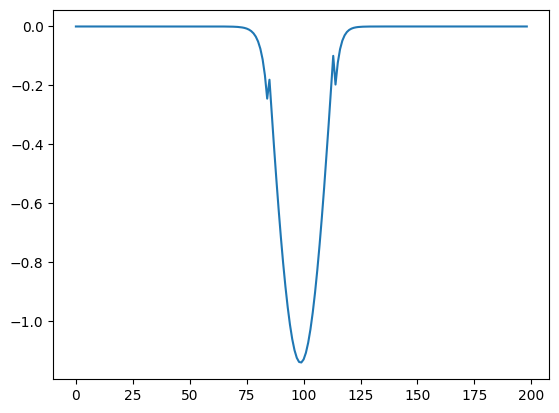

Epoch 6249:
  β² prediction ≈ [ 38.090225 126.907295 192.69792  195.64282  185.80687   99.77293
 173.19876  113.60484  189.36838   36.647835 102.65187  137.32224
 213.81355  111.36345   93.88263  275.18036  169.0428   364.35696
 234.47812   30.671722 406.02405   31.526976 130.6946   365.78967
  69.89425  121.12471   94.59583   97.02787   61.166965  57.65033
 112.04149   66.46012   87.07652   35.323235 160.2176   138.82016
 217.62325   81.28917  179.96346   59.986362  81.16025  155.1119
 255.04436  132.2149    41.801136 122.19918   93.565575 199.47894
 108.72632  228.03374   40.538345 134.10371  216.93558  178.59715
 153.97849  131.26825  209.58417  139.69545  200.92773  165.17159
 135.75938  153.66151  106.72935  323.17825 ]
  β² max ≈ [ 39.59602  134.78128  200.93767  198.4311   188.83116  102.07415
 175.54771  117.09358  192.7378    38.85623  106.2684   142.38535
 216.49577  115.0129    97.125626 278.63745  173.48094  370.4679
 236.89552   33.315662 413.25082   33.18147  132.40086  3

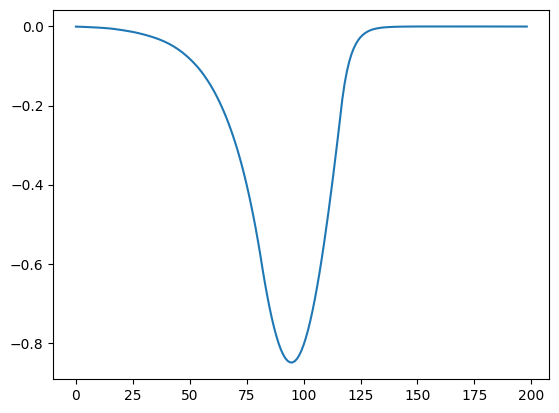

Epoch 7249:
  β² prediction ≈ [ 52.851025 160.57921   68.17029   34.668663  59.6302   186.0473
 225.52734   47.741604 325.8241   104.54316   75.90331   54.92514
  99.729324 122.31004  200.42001  393.87906   54.442375  88.911125
 102.62079  157.28581   79.377014  30.385836  50.259407  99.69148
 125.12504  155.35278   70.4748    75.406395  25.12789  186.66484
  82.527695  93.22687   62.6879    46.75961  155.27011  100.79986
 131.34337   47.49892   83.754715 153.65149 ]
  β² max ≈ [ 55.811047 165.28584   70.89596   36.58485   63.735325 190.0371
 229.81801   49.391045 330.84955  107.36522   79.28234   57.159267
 103.287056 127.020035 202.8056   396.39633   58.525574  91.255516
 106.2684   161.16245   82.55868   34.16887   52.448467 105.66246
 127.43966  159.80196   73.73955   80.26969   26.665146 189.33012
  85.1849    95.8961    68.08969   48.80203  158.478    105.08273
 137.57195   53.066483  88.282906 156.15778 ]
Physics Loss: 2.016350e-04  Total Loss: 2.016770e-04
Epoch 7499:
  β² pred

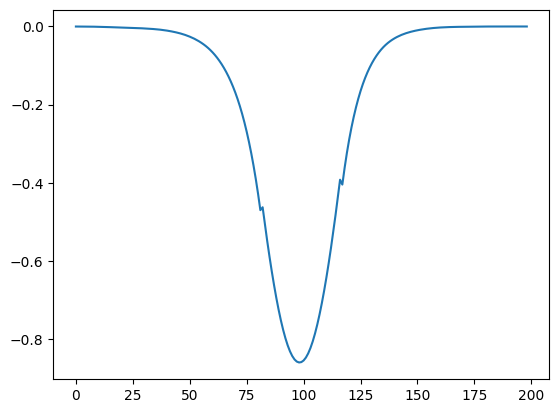

Epoch 8249:
  β² prediction ≈ [116.55917   77.92375   91.15465   45.380547 403.87433  255.6206
  91.221176  48.192036  82.328606 209.67549   53.45601   40.88882
 200.8462   167.0468   133.18811   70.194695  73.35161   52.29503
 143.80489  118.21106   93.23283  103.73227  128.83826  128.36469
  83.09536  365.79596   98.48559  137.44246  128.97974  226.07254
 115.59605   46.33479   77.15403   64.73049  261.4742   155.78778
 189.37628  276.66367  373.2498    30.356972 186.05951   54.90136
  65.77266   50.755245 144.24052   55.873756 113.676674 453.41803
 188.06897  112.34362  251.03781   72.49552   81.11489  142.19212
 219.32819   84.78449   45.027767 285.11728  157.92833  127.35938
  30.75896  166.51978   75.506935 176.27533 ]
  β² max ≈ [120.54599   82.25652   93.052216  47.65007  407.00266  261.56723
  94.461784  49.808144  86.22942  215.40755   58.2804    42.073273
 203.75969  172.1392   135.5426    71.85505   75.395325  55.901196
 149.48674  120.52089   95.8961   108.761185 133.4179 

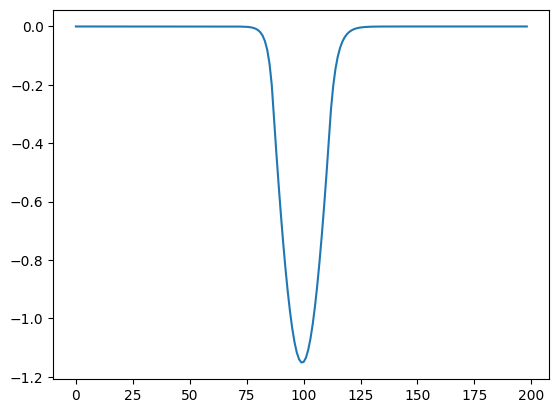

Epoch 9249:
  β² prediction ≈ [130.69307   44.041767 126.90605  364.3474    41.15772   37.319054
 105.4053   109.750854  86.78286  178.87706  412.01358   45.565998
 240.62062   50.779778  86.72736  419.6263    59.45367  260.6241
  45.394047 260.21292  200.42943  170.9712   166.74152   83.714806
 189.47528   86.8576   127.09171  276.65833   43.412888  78.38074
  42.59103   83.08516  142.44398   88.93655  101.3801   156.24297
  91.05303   93.88159  226.86795   76.46919 ]
  β² max ≈ [132.40086   47.29556  134.78128  370.4679    46.833763  38.77381
 109.18456  113.621414  91.87466  181.0843   416.59302   50.047035
 244.38663   53.841328  89.515305 423.65698   66.09275  263.1095
  47.65007  268.70947  202.8056   175.21434  170.7967    89.12163
 192.46095   90.82287  130.97894  283.68964   44.87179   81.95233
  46.889523  85.44754  145.86024   91.496376 104.760666 158.3638
  95.645706  97.125626 230.31424   78.722374]
Physics Loss: 4.822437e-05  Total Loss: 4.823246e-05
Epoch 9499:
  β² pred

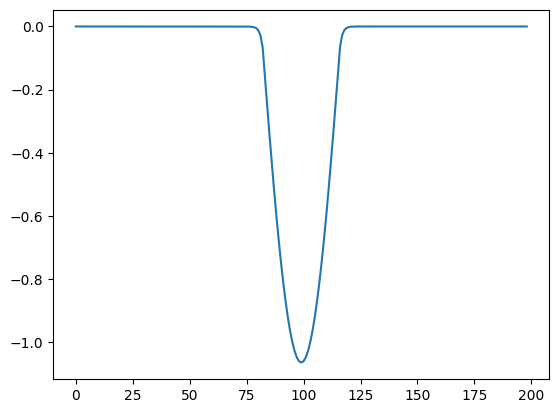

Epoch 249:
  β² prediction ≈ [264.7396   219.1261    40.119896  68.16204   38.80963  272.40466
  54.100113 283.993    215.2154    42.37369   56.029446 243.61584
  61.120613 160.93271   52.519005 434.72757  130.81787  120.89714
  57.671173 284.70428  173.93652  376.88248  278.88565  100.15812
 285.69977   95.530365  93.403114  78.37526   58.77071   88.21033
  35.46652   99.2137   171.22998  169.09024  138.16441  162.38112
  99.07884  111.099556 226.25063   65.042145  86.24699  113.35208
 164.40747  246.07079   40.42439   65.45401  235.34346  247.40057
 307.75412   47.11544  255.11852   72.92292  126.80884   75.59623
  46.995472 204.17747   86.47581  188.12662  107.69691  122.05567
 351.80145  245.79497  477.19754  183.57666 ]
  β² max ≈ [264.7396   219.1261    40.119915  68.16204   38.809658 272.40466
  54.10013  283.993    215.2154    42.373695  56.029446 243.61584
  61.120613 160.93271   52.519005 434.72757  130.81787  120.89714
  57.671196 284.70428  173.93652  376.88248  278.88565  

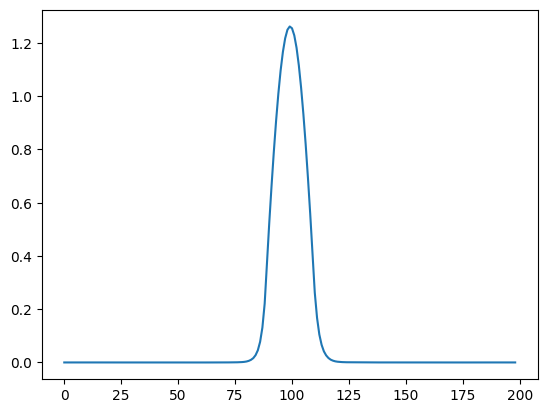

Epoch 1249:
  β² prediction ≈ [ 82.23505  107.7097   303.14105  202.46721  100.71285  118.83905
  70.46711  143.1337   117.391884 135.0627   214.10556   88.641624
 107.53454  194.23332  103.51309  152.63757  175.35724  142.59103
 115.232796  51.393818 172.90335  152.68619   61.577644 134.24529
  23.266985 245.02747  124.04653   33.90144   50.512245 126.8828
  94.23253  312.4989    93.72815  121.74439   28.004007 288.5689
  46.877735 251.61649   19.155838 137.47168  214.36449  139.22069
 104.786514 203.93414   85.800446  37.454857  37.959274  70.000046
 132.87675   18.372194  44.49816  103.23578  123.35527   58.281036
 183.21982  180.97453  353.24448  247.33926   45.67368  343.34634
 115.25887  116.91161  363.07462  141.21318 ]
  β² max ≈ [ 87.81818  110.37974  306.7833   205.3782   103.23397  121.47262
  75.826195 151.02577  119.70908  137.60143  218.03062   91.237495
 110.374275 202.40132  107.319    155.07906  180.84412  145.51495
 118.159836  56.470196 177.54874  157.48326   64.4738

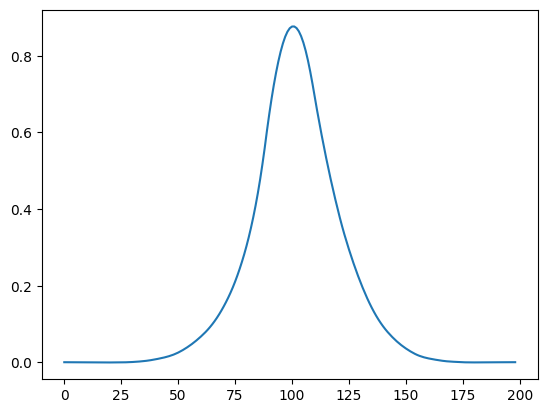

Epoch 2249:
  β² prediction ≈ [101.1389   296.44748  100.71178  151.33247  224.64142  118.7332
  80.69546   52.791626 178.62505   98.01038   48.72302   79.27899
 167.8839   344.2386   130.16724  179.59305   98.54228  103.233734
  74.5931    69.803154  46.545937  67.9285    61.448174 159.56255
  33.73263   96.92406  218.08638  158.43794  300.5382   157.74843
 153.20833   64.4635   164.77396   78.691376 240.13068  149.26738
  57.182163 219.22314  193.01233  201.5819    57.02836   60.78298
 405.61505   47.814026 102.97808  341.3252    86.28594  107.05897
  52.338993  62.87678   68.8587   194.31467   50.505413  83.692986
 171.8027    46.685955  97.0018    47.933144 125.36604   21.974855
  36.66758  201.28613  378.96814  220.05843 ]
  β² max ≈ [104.198135 299.1694   103.23397  154.34515  228.43918  120.957726
  85.51502   57.853893 181.60208   99.694824  53.22424   81.61284
 171.22998  348.07904  133.6913   183.14624  102.89342  105.515205
  77.494514  71.64322   47.739933  71.81682   63.73

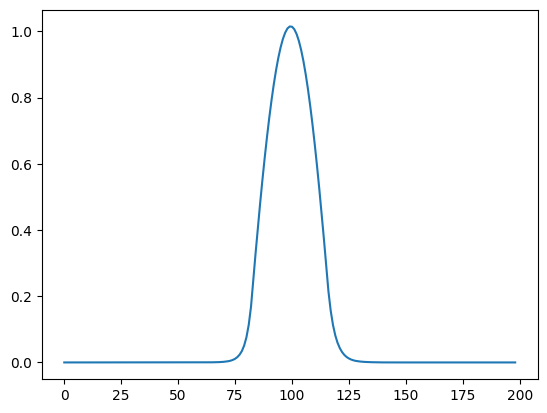

Epoch 3249:
  β² prediction ≈ [123.48004  159.14172  221.69414  108.197685 104.6688   155.22305
 249.4551    52.63749  309.15805  134.27124   63.404625  60.096397
 212.2721   114.53407  109.77149   74.35923   60.77333   77.57424
 207.11559  247.42548  129.91385   49.25438  117.04334  383.86636
  89.439606 114.39455  139.73167   88.41875  142.59964  273.60147
 156.50699  121.9584    70.34855   62.919655 363.71628  167.00386
  80.74962  152.5822   236.85817   39.494564 190.54137  130.18283
 251.7588   178.52475  107.408966  93.26765   46.44492  143.37071
 129.29852   41.346344 160.23386  199.27502   97.75053  287.0911
 150.23407   54.916378  58.54683  121.81271  124.212135 124.576744
 149.33723  155.79315   53.99417  167.00594 ]
  β² max ≈ [126.96915  161.5688   225.58405  110.60985  108.91191  158.1428
 252.84006   54.282673 312.63727  137.92549   64.978455  64.25277
 215.2154   116.82794  114.646454  79.45546   62.27054   79.36821
 209.85239  250.45164  133.96004   50.91283  121.16241 

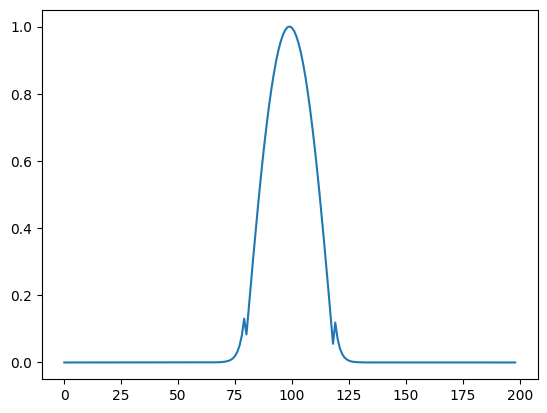

Epoch 4249:
  β² prediction ≈ [363.50378  138.36919   51.98013   83.12337  107.889206  61.120274
  45.589767  38.04428   56.796543 262.23013   87.8839    68.61213
  47.36598  105.975975  69.421196 155.16245  132.14868  149.8071
  48.030815  75.42117  106.33781  307.1343   286.4431    85.10498
  76.63837  102.92382   84.52214  331.1243    53.571583  42.521286
 122.38315   95.29651   46.662876 192.59465  173.00555  121.19442
  58.169044 144.31888   43.980774  77.670074 145.01115  201.78185
 326.34106   52.52827  133.2609   140.42274  227.05238  156.73795
 268.70428   53.010284  20.271524 183.90329   73.31371  331.67343
  86.318726 137.59062  194.37389   98.54203   95.85513   47.61098
  70.8279    96.53538   53.69642   49.416615]
  β² max ≈ [368.82404  141.62743   54.64421   86.8376   111.70105   64.46102
  49.04149   40.21524   59.45265  268.144     90.58193   71.147224
  50.115948 109.91802   74.51448  161.34438  134.6802   153.94327
  52.317047  79.97844  111.25262  310.58487  293.3850

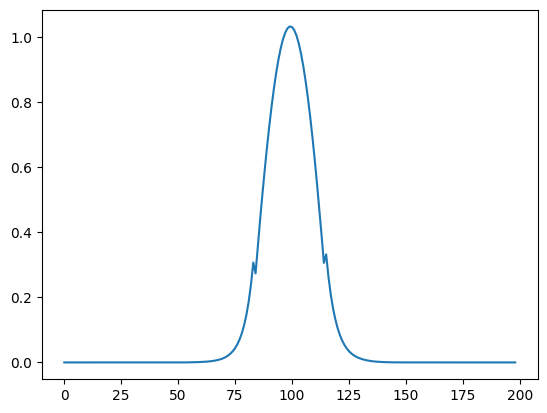

Epoch 5249:
  β² prediction ≈ [215.28908  125.25116   83.60528   91.11354  228.30008  278.31448
 201.65077   76.98861   54.529247  52.330845  58.840694 132.7928
  83.5232   101.09957  229.43364   43.137627  70.34768  369.6884
 260.49216  156.82776  140.2344   112.20199  148.65187   49.920547
 110.55542   45.918716 114.43049  243.03406  142.30766  150.15306
  35.04717   38.23262  121.55713   50.486553 212.65633  453.0802
  66.17968  126.12091   82.774574 240.65775  122.93468   54.672195
 276.48508  102.3182   234.86903  291.18997  339.35098   33.305584
  64.710144 106.110054  68.62619   31.40903   90.414536 169.7232
 125.63421   34.816086  30.494566 191.29898  250.7192   150.41934
  26.072083 115.35539  163.0934    29.300343]
  β² max ≈ [223.43155  132.28125   88.35729   93.00831  231.5962   281.6424
 204.0832    80.845634  56.276936  53.84321   60.725777 135.70476
  88.45371  104.19413  233.25008   47.288868  72.46708  375.75656
 265.00342  160.90334  144.26903  114.419136 151.56566   

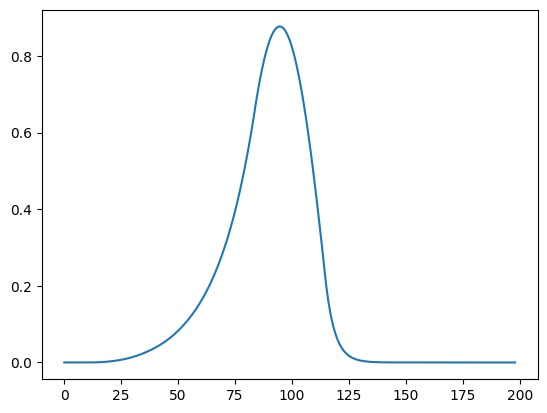

Epoch 6249:
  β² prediction ≈ [ 68.61012  128.08101   23.19387   36.178406  58.93057  156.98346
 411.08112  113.99221  113.46507   97.737434  59.438747 261.665
  74.31675  121.08441  163.40356  268.64395  196.29828   45.056923
 137.87692  158.8497   115.92474  111.25926  291.01743  146.76434
 177.1324   369.07675  102.63061   79.5356   144.77568  343.1738
 273.91287  214.57892   84.47624  230.45215  177.98546  249.40683
  66.04752   56.27433   43.885067 170.88403  187.06177  311.38013
 341.3974    87.7044    44.121315 200.91852  323.7417    51.28982
 133.09239   57.82746   49.04087   79.51568   28.47494  195.29028
  90.01483  127.98029  129.2884    88.61879  192.1556   153.3372
 208.61212  186.27052   56.03474  231.82558 ]
  β² max ≈ [ 70.87193  131.93912   25.093868  41.381203  61.17942  160.76393
 413.593    118.42762  118.629265  99.90468   62.035164 264.7396
  76.233154 127.37699  166.27266  271.14935  200.58289   47.59906
 140.98767  161.80313  122.05567  118.00698  293.78122  149

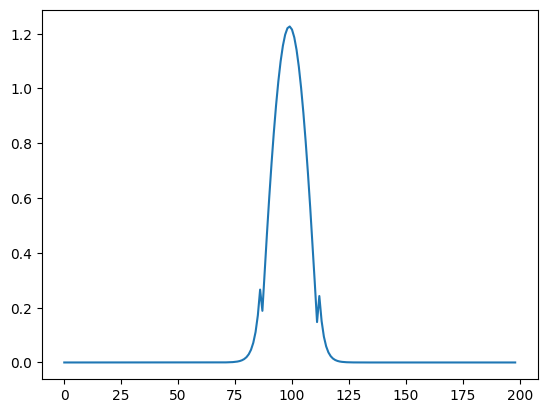

Epoch 7249:
  β² prediction ≈ [212.36678   59.4246    31.707806 123.33121   78.930916 199.50063
 181.38141   43.805798 112.249275  44.014256  55.04861  174.54408
 150.34192   77.253136 169.32626  132.0784   216.60126   52.617256
 156.12119   37.42046  131.6964   170.81996   71.055244  83.57724
 153.34116   93.961235  99.377815 186.9242    97.66717   45.1963
 243.17609  170.73811  130.45581   48.856796 148.15463  137.51974
  89.6971   320.18726   87.426445  32.70933   19.798906 126.09428
 232.68832  288.10577   42.57581  117.750244 148.31929  239.07431
  30.886517 105.44436  100.57493  328.01758   93.01406  100.296616
 107.92241  369.094    100.14072   79.237206 121.082664 134.8124
 206.37614   85.39362   79.29686  135.1988  ]
  β² max ≈ [215.48717   62.11627   34.2142   130.86247   81.592026 208.14539
 183.48877   45.431995 118.25811   46.995472  59.314304 177.23766
 152.85945   83.75744  171.94165  138.31332  221.59282   54.325977
 159.12138   41.28514  138.71887  177.3504    73.27785

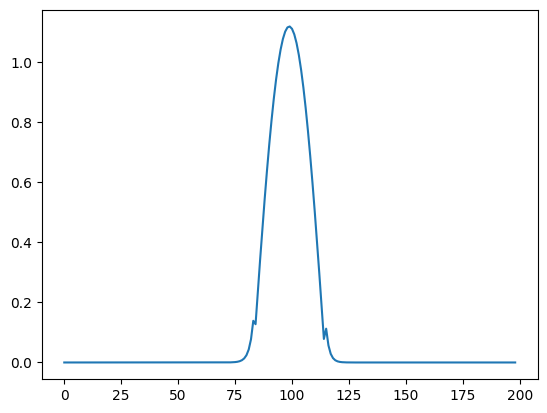

Epoch 8249:
  β² prediction ≈ [ 94.047585 117.03697  286.83368   44.364388  67.76022  131.45863
 150.02975  202.66287  167.33817  123.03556   35.08218  178.91634
 118.40217  437.57062   56.130234  87.6898   104.303764  82.92846
  84.46841  143.27113   93.60255   63.68334  174.54926  153.4441
 400.635     45.39888  161.73993  118.1656    62.76879   81.77089
 221.81264   88.257416 164.6387    64.44297  205.87993  134.32195
 152.94269   78.13118  108.28812   66.91758  182.09995  223.34584
 208.65617   77.59579  162.6087   373.4836   300.50345  192.19049
 208.63786   90.24833  218.16098  271.95233  143.3966   208.2181
  18.66463  112.56327  291.1175    48.706097 136.74008   84.87568
 117.44907  145.45428  117.2334    99.260315]
  β² max ≈ [ 96.67198  122.05224  289.5613    46.95902   71.81955  134.5199
 156.98016  210.80423  169.68088  126.911064  38.823975 183.3318
 123.704956 441.08914   58.81094   92.418274 107.0493    87.154175
  86.47809  145.31155   98.55745   66.1429   176.92001  15

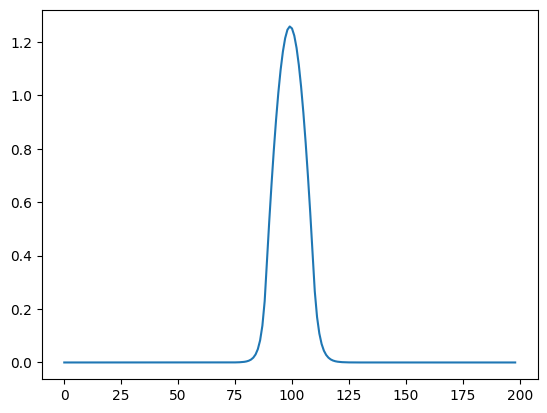

Epoch 9249:
  β² prediction ≈ [401.41525   79.81244  188.50594   57.535477 277.7314    41.032215
 142.90828  214.1001   396.65622  262.98114   36.68778  432.44843
  86.68066  185.92262  143.85686   54.254185 180.14172  139.19646
 172.788     90.31023  168.15454  307.11368  116.19822   36.785507
 184.02805  103.14795  114.18289   34.843235 162.60118   94.03441
  46.62308  136.86281   90.349266 146.3759    76.10407  111.873116
 112.50613   48.99599  118.610275 139.09328  115.90802  138.54524
  68.33954   96.80122   39.760174  93.970116 148.79831   48.594334
 111.54481   71.61984  199.11176  171.14368   56.38657   23.24733
 108.719444  64.25161  110.94431   72.76955  154.47185  159.84203
  84.2247    48.58306   67.90427   52.994267]
  β² max ≈ [404.92123   83.160706 191.26509   61.120613 283.62988   43.69557
 145.89815  217.12495  399.4669   268.86206   38.553436 435.2345
  90.91308  193.01505  147.2366    56.325333 185.23384  141.94637
 174.97603   92.75014  170.85922  311.53568  121.358

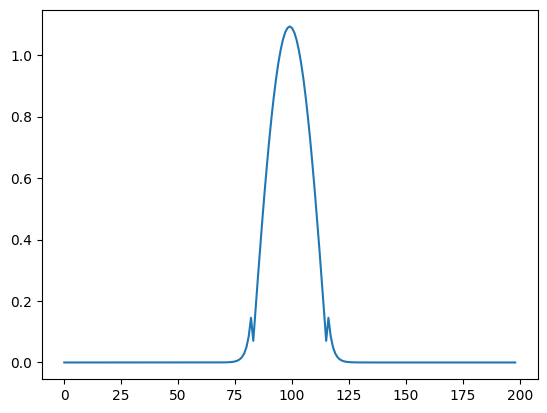

Epoch 249:
  β² prediction ≈ [ 48.313583  23.385818 413.34235   63.71444  197.43983   57.695454
 391.9079   151.93451   51.56166  137.72026  108.42446  267.02145
 158.33398   65.130264  43.270515  45.14475   87.46617   93.851425
 133.19864  170.70082  147.10757  137.65845   55.63501   81.05098
  79.39469  127.472206  91.114235  79.150345 428.53925  124.75635
 100.27681  147.86415   92.85522  106.7697   176.26039  213.83852
  23.820412  68.198784 141.48952  266.29312   46.78676  123.1765
 109.59689  112.66936   62.423725  41.39523   53.639458  46.32548
 127.111725  63.106724 279.84167  243.83257  278.09525   46.75342
 257.96295   92.21338  125.18987   95.18936   31.526085 175.25885
 184.79274  110.99862  239.67035  232.37488 ]
  β² max ≈ [ 48.313583  23.385818 413.34235   63.71444  197.43983   57.695454
 391.9079   151.93451   51.56166  137.72026  108.42446  267.02145
 158.33398   65.130264  43.270515  45.14475   87.46617   93.851425
 133.19864  170.70082  147.10757  137.65845   55.6350

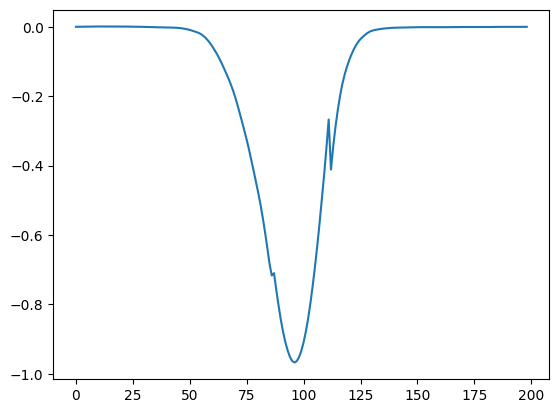

Epoch 1249:
  β² prediction ≈ [ 91.30123  110.2105   153.38972  102.31158  123.012344 163.21472
 126.99184  118.785774 176.98398  119.16803  102.684845 363.785
  40.85248  360.9626    77.08098  113.10818  438.39844  127.16747
  30.375776  60.846394 153.0655   138.60101   93.68673  220.21362
  37.14211  152.63368  202.74425  130.43994   23.717539  23.250744
  64.89108  153.57072   59.180477 175.55334  192.77702  140.96501
 130.89038  148.72462  370.25043   96.84722  294.34875   57.39479
  61.928707 178.00494  172.99815  120.92508  152.4054   122.67651
 241.49187  328.53522  273.02713  335.63104  109.8154   111.52609
  46.764874 140.13109   58.894672  37.702347 129.46121  175.79007
 229.9432    40.598114 119.1648   111.7638  ]
  β² max ≈ [ 95.63372  113.2231   159.60284  106.12453  125.93286  166.3729
 130.9954   121.298485 179.57079  121.65865  107.603355 366.47614
  43.59011  369.1732    78.913376 116.943146 447.26132  130.72255
  33.48997   64.72164  155.65456  145.62065   95.977554 2

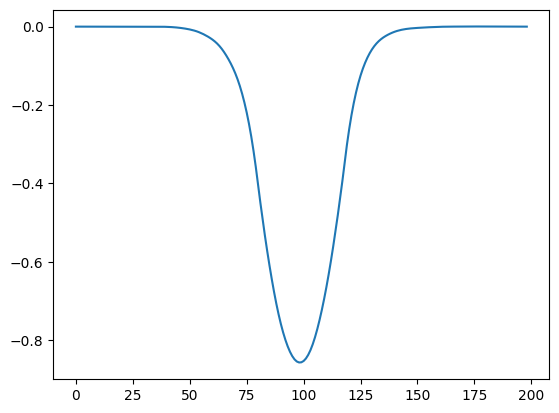

Epoch 2249:
  β² prediction ≈ [ 97.87118  405.77     104.01466   69.54205  238.29558   36.283066
 107.1402    79.81577   50.71539  131.17354  152.04675   64.01557
 308.7008    22.745459 194.58427  156.08528  127.60138   57.89518
  97.85859  297.7083    33.35198  153.23373   53.941837  76.39764
 241.01987   71.93209  100.19211   29.733143 164.18198  110.905525
 373.35956  321.97113   44.853123 394.76978   45.22431  110.94638
  85.0894    67.30333  156.85501  150.42923   43.886105  65.85761
 178.1903   115.27455   50.702805 126.88398  147.86415   99.370186
 116.53683  323.13687   48.015858  68.19866  139.26773  193.87373
 154.32619  181.35516  170.05338  256.3247   235.42407   77.72824
  53.24658   30.78701  203.67603   61.17122 ]
  β² max ≈ [101.90754  408.87122  107.05573   74.39208  243.20662   37.834644
 112.25049   83.1456    57.706184 135.28477  156.16328   65.721725
 313.1767    24.012018 197.3138   159.2909   130.04729   59.53999
 100.55603  301.6838    36.700146 159.60284   57.5

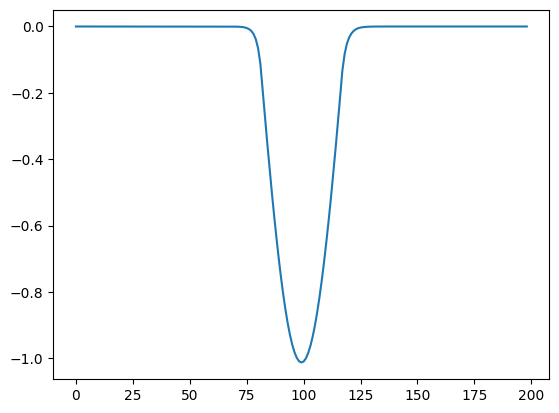

Epoch 3249:
  β² prediction ≈ [ 49.730637  74.32469  105.84588  265.61575   70.90483  119.06754
  40.817852  73.45729  127.06387  322.97546   56.17455   54.81038
 129.32933  314.54102  181.69362   44.619274 291.9377    82.33424
 146.39055  406.7378    47.95206  109.30577   76.79086  449.73428
 165.72385  145.48769  202.74286   35.376656  85.71324  159.39018
 195.25162  126.45791   80.02118   71.66332   76.1217   109.55676
 266.90747  120.21495  133.1538   133.65283  341.13138  126.06443
  78.30873  101.9344   141.5916   104.11204  160.03683  216.45358
 190.42696   76.38432   80.07749   30.47942   77.24278  241.29184
 204.10263  125.106094  56.303085  64.9925   243.88292  112.62325
  94.32585   35.76088  171.12103   85.88372 ]
  β² max ≈ [ 52.00483   77.26508  107.72269  274.37784   72.61626  123.55294
  42.698887  76.49087  129.67105  331.31378   59.05658   57.043583
 132.5806   318.03354  184.71162   48.614407 297.9522    86.0024
 150.87997  412.01788   51.38614  112.67029   79.67644 

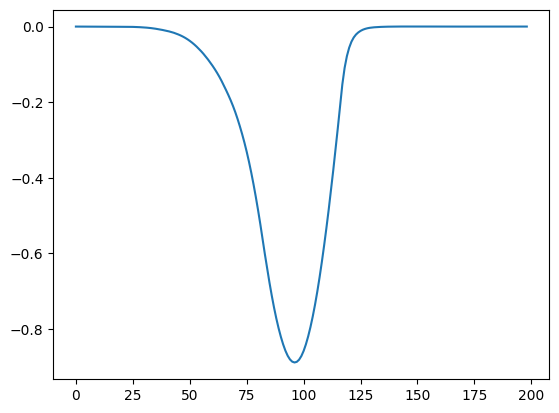

Epoch 4249:
  β² prediction ≈ [ 64.908424  16.540798 128.4942   269.23715  242.21573  127.5656
 113.109695 111.679535 118.01265  180.15138  116.77769  286.3473
  49.54549  120.05967  117.77789  115.76615   20.0941    78.88529
 253.849     95.236916  43.014626 115.32701   83.13798   98.67155
 151.72757  133.0946    44.308815 228.62949   87.86088  239.80925
  28.94003  123.55238  209.9938    43.98996  168.06853   52.573772
 114.38157  236.5816   115.41294   98.361496  96.21499   29.759027
 145.78659  120.460724  95.88746   38.273327 299.314     65.39323
  80.733025  63.4347   100.76494  294.87106  109.53371   95.80339
 113.691536 159.39008   94.71375  132.9384   226.71556   53.286667
  63.375805 110.93012  186.99123  387.60562 ]
  β² max ≈ [ 67.846794  18.15128  131.98517  277.67932  246.76414  133.62354
 117.37008  116.30415  121.3997   183.114    119.87655  288.81067
  53.18705  122.74807  121.66867  119.764465  21.666983  82.55357
 261.02936   97.29502   47.079594 123.539444  85.09237

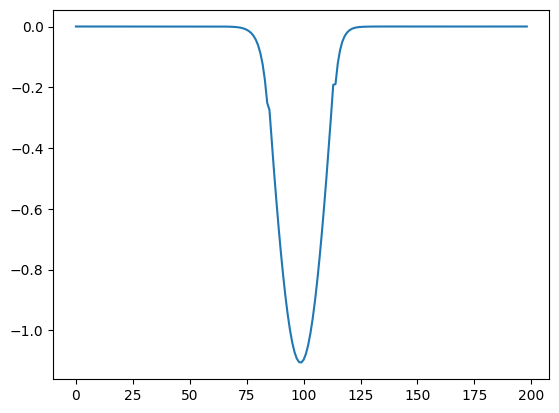

Epoch 5249:
  β² prediction ≈ [202.61751   60.560852 252.79666   55.016617 136.22974  262.37582
 274.25363   72.95451  157.38547  170.61943   60.248104  66.63401
  54.189995  94.906204  73.57246  144.69876  384.68594  140.99
  41.963753  54.151955 177.43306  156.5242    29.984333 239.77034
  20.116644  88.08757   94.74839   78.44941   51.96764   79.69666
  41.541477 137.37059  200.39244  239.82176  186.33505   71.65803
  71.623726 379.6173    39.387924  58.11935   69.492874 216.27748
 232.64897  386.62836  127.68011   59.030205  84.90045  172.08418
  60.965588  55.204845 166.52637  326.64612  295.586    137.84093
 230.35527   88.80824  225.24844  121.32873   40.70248   81.81567
 148.90205  116.68259  347.2949    44.811977]
  β² max ≈ [208.28464   63.955795 255.8571    58.115826 138.81665  266.29312
 279.37485   77.20038  162.50287  175.70494   63.919857  73.3522
  59.143074 100.41289   80.92706  147.96475  389.90756  143.93692
  46.690025  56.203346 180.7393   159.80388   32.092358 244

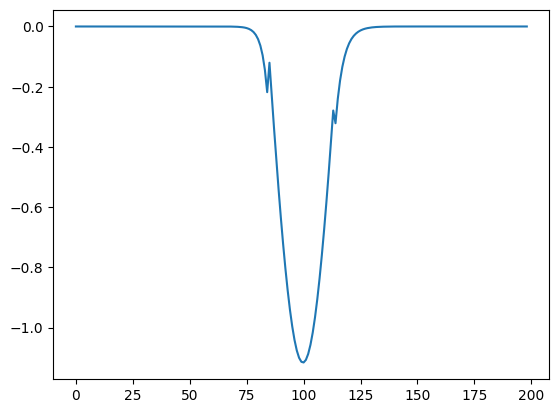

Epoch 6249:
  β² prediction ≈ [124.80348  111.46123   81.51067  138.60751   43.336304  72.07222
 113.84942  242.6237   184.90962  219.62497   49.538128 223.2272
  42.474243 135.5721   154.03703  428.95737  190.55234   76.234085
  83.92187  324.99023   84.83077  204.05243  351.55295   54.21237
 283.86334  200.52054   58.320103  81.6046    26.289455 141.6696
  34.106224 330.60428   68.10889  373.2857   371.79214  159.43336
  75.10227   93.81335  120.819984  33.483894 164.11691  209.00711
 143.7512   225.10773  189.68944  154.10461  188.6803    78.09509
  15.214159 230.33432   84.75292   33.227493 136.66777  104.306755
  66.627945 144.72781  313.14136   53.25158  220.60655  131.44994
 118.68496  288.77344  164.60432  107.99086 ]
  β² max ≈ [127.38109  116.574875  88.17642  141.75912   45.14613   76.28502
 117.029144 245.34384  189.9996   225.28912   53.18705  230.14613
  46.021206 140.95311  157.35303  431.25034  197.46765   80.04269
  88.44986  330.90622   89.636955 206.59677  354.36435 

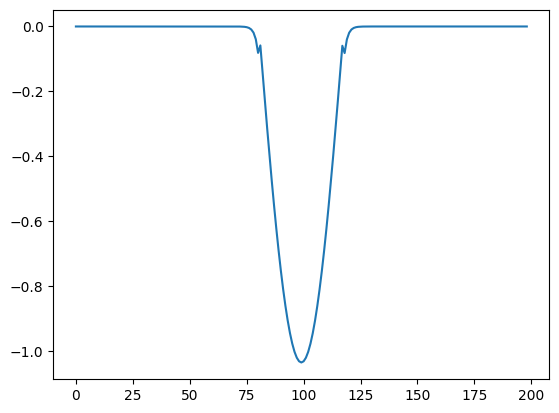

Epoch 7249:
  β² prediction ≈ [123.33012   89.62263   32.21143  149.72675  148.65529   62.010544
 167.50648   60.11858   68.567955  64.44181  112.47691  112.04279
 110.21154  117.94555   51.15509  110.68241  202.16496  139.11526
 116.05385  100.92718   58.84115  167.81288   85.14235  107.843025
 245.1747   259.96783   50.41826  119.87522  158.3385   144.27318
  77.67068  243.32217   40.848873 171.60194  235.55315  199.8102
 249.80638   41.525574 248.76585   95.60465   29.239677 112.95087
 167.61096  176.51082   64.404655  38.4999   189.00821  426.0167
 169.22847  104.36907  313.2395   146.30342  370.03693  124.36179
 353.20682  171.24736  328.72382   44.081963  40.25049  108.80627
 122.0699   343.91034   74.01288  127.37647 ]
  β² max ≈ [126.925545  93.12667   35.329422 154.49983  150.99649   64.971794
 174.54387   63.116707  70.62655   66.140686 115.95493  117.88709
 113.63775  123.684616  52.992096 115.20948  205.49747  141.99593
 119.07567  105.93792   61.916725 173.763     88.71377

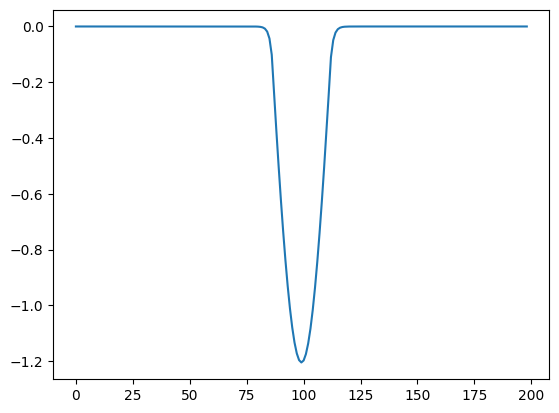

Epoch 8249:
  β² prediction ≈ [103.67151  336.5707    85.741264 105.66522  421.6534    80.82612
 105.99903  127.529625 189.73885   43.240307  57.054657 148.8173
 201.31017  179.02635  127.53831  324.7656    92.069214  51.455853
  78.37466  140.96284  225.33658  253.92258  421.3919   126.88247
  65.19634   41.998356  76.144905 128.53925   34.880836 175.02419
 360.90643   49.958393 353.78186  130.75485   73.59084  165.18471
  40.343174  93.36252  162.39253   69.49088  159.76707  370.93982
  57.49143  366.5592   174.87808  100.78099  433.06335  176.57901
 377.41443   72.188965 100.82674  304.7732    93.994354 444.46854
  86.52175  114.5638    67.82227  438.23837  243.0085   207.02611
 163.68942  478.89725  119.131004  96.27051 ]
  β² max ≈ [106.48078  339.34662   88.991714 108.396126 427.74124   82.449135
 108.88416  129.66034  196.41862   47.0405    59.332302 151.12135
 203.77914  182.9764   129.64763  327.5469    97.12316   53.04242
  80.04649  143.86586  227.71783  257.74545  426.69504

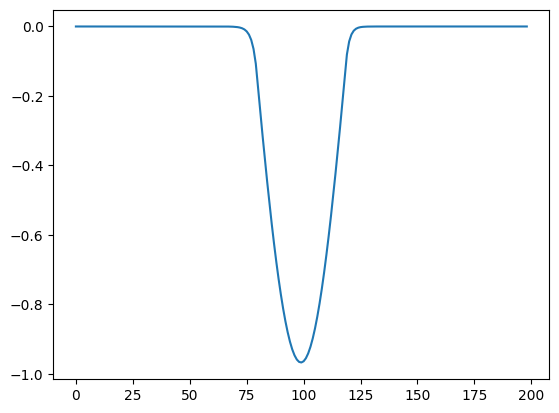

Epoch 9249:
  β² prediction ≈ [101.520615 123.592995 174.8826   154.14525   74.173904  33.631447
  43.546097  76.22462   86.055466 126.35838   77.087    116.11726
  97.687874  12.53065   90.30524   46.71931  139.64874   51.249504
 429.80444  145.0648    64.54363   24.89112  149.77773  111.42699
 285.71924  227.61061   52.599716 267.85812  414.61536  164.81294
 428.66928   68.64806  180.01495   56.716587 192.97868   40.212807
 252.50546   67.75303   65.888405  38.243    150.87817  212.96669
  77.263725 284.13828  141.84666   18.204456 195.32904  237.751
 163.32819   46.282467  22.916988  42.025684 302.71298   89.09562
  94.733116 293.7512   159.76674  321.98914  103.99829   46.624214
 100.49501   40.85971  242.95653   44.168713]
  β² max ≈ [103.75884  125.904884 180.31795  159.93254   79.04017   36.025745
  46.806618  80.420784  88.24488  134.01653   81.240234 120.079216
 100.30836   13.679126  95.01826   48.86294  144.32118   54.03079
 435.916    149.43436   71.05393   28.807135 151.93

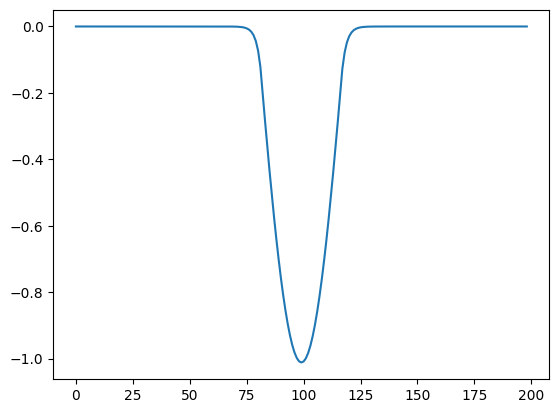

Epoch 249:
  β² prediction ≈ [ 31.346682  64.30169   44.657574 161.08913  280.3004   260.96323
  40.61124  131.09885  244.67941   38.83967  358.05093   47.764988
  90.0173   231.72763   25.319946 125.35871  166.41762  173.22736
  78.52078  180.96553  109.39854   29.41837  182.14365  210.32565
  54.381947 161.65948   47.442726  35.199665 215.35599   31.525087
 117.69708  300.3526   337.4099   244.69469  246.25523  160.5196
 472.34457  230.03952  204.61267   77.68251  273.90762   39.431953
  65.09528   43.26283  144.10887   53.00653   67.17021  214.77208
  76.54536  136.81593  101.85613  151.2579    69.67772  173.22183
  34.10958  390.5026    35.19494   53.472763 152.45097   56.606113
 145.71352   48.85664  140.98608  280.70996 ]
  β² max ≈ [ 31.375206  64.30307   44.660114 161.08923  280.3004   260.96323
  40.611855 131.09885  244.67944   38.840893 358.05093   47.780792
  90.0173   231.72763   25.320322 125.35871  166.41762  173.22739
  78.521286 180.96559  109.39854   29.418695 182.143

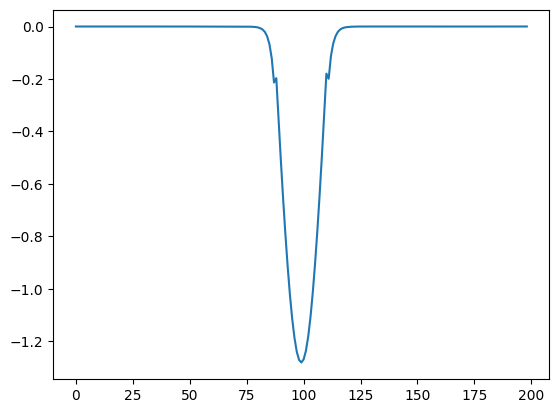

Epoch 1249:
  β² prediction ≈ [ 69.65532  253.06976  136.704    192.48993  149.10452  131.93762
 450.6708    76.12083   57.482643 152.8972   378.68506   57.858665
  59.23352  215.96346  165.16614  138.61974  216.3701    61.446926
  40.95624   60.324467  76.101685 192.16318   24.970703 114.8274
 396.18408  105.01066  170.07732  123.45615  418.42334   72.59532
 165.57887   31.751587  41.143936 236.98178  193.96295  174.49089
  42.213554  49.508858  21.374218 413.35736   79.4488   425.88696
 266.61893   50.98942  132.77585  117.338394  78.76799   68.79961
 349.5574    81.45523  447.11606   28.97676  183.97481  137.54936
 100.7576   169.68213  228.5008    28.9445   259.9081   381.77057
  91.421875  77.82897  110.781334  62.9771  ]
  β² max ≈ [ 72.187416 258.9453   138.84486  199.0059   155.62743  135.491
 454.18347   80.18899   60.28832  159.15437  381.28265   60.64329
  61.747997 219.02463  171.60956  140.79402  219.6158    66.69992
  42.398396  63.37356   78.748436 196.36508   26.754112 

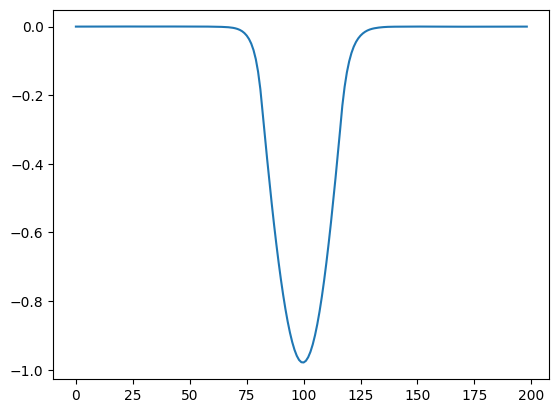

Epoch 2249:
  β² prediction ≈ [243.52391  106.87894   27.587637  67.7072    97.697975 177.33508
 110.1286    65.59413   46.29511  154.5026   133.27605   59.53489
  77.47502  186.32779  358.7708    72.86086   95.52961   85.134926
 207.84894  375.17883  115.44175   79.25236  156.55212  239.47643
  87.53359  157.45564  369.63144   39.14859   52.145588  61.53684
 201.17334   48.745434  51.55607  135.56023  126.80691  106.44276
 152.94052   78.28738   86.8133   262.6845    47.34004   39.661964
  68.174835 314.18793   60.23116   39.947353 117.5189    82.36027
 212.16267  129.15239  190.91759  248.47568  168.17139  195.62476
  85.79412  366.8346   117.69952  204.96466  180.35951  109.79778
  27.15588  111.73059   50.38745  118.58544 ]
  β² max ≈ [249.41214  109.550964  30.106806  70.28665  102.106735 179.64233
 112.05811   67.78475   49.387856 159.44211  136.77957   61.351765
  81.74089  189.17505  367.258     78.733284 100.62386   90.589584
 213.26723  377.34833  119.750854  81.50247  159.99

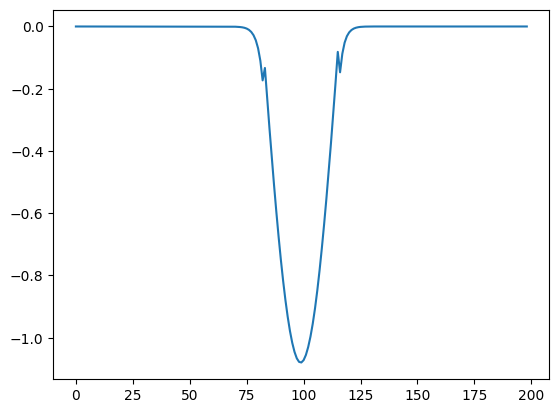

Epoch 3249:
  β² prediction ≈ [154.63637  138.887    171.13226  145.24048  211.02542   48.272526
 185.98982   19.335283 137.75725  109.21147  235.07983   53.200565
  81.804276 109.03954  168.75435  101.7302    68.838646  75.61638
 123.17239   33.96272   47.32581   57.2384   190.44221   34.063213
  39.56998   33.05502   24.453676  73.56972   73.009865  40.043297
  97.02207   77.30651  114.29431  221.31873  225.31949  133.81091
 129.21025  108.01962   78.57307   52.868626 122.7987   334.77112
 129.74098  175.07297   53.459988 102.49117   59.52398   92.21371
 173.78207  113.87321   49.91915  106.48441  304.72635  234.75569
 119.90577  264.94562  175.46109  125.02875   81.3156   143.50165
  48.130177 377.12778  109.497505  57.215588]
  β² max ≈ [158.72041  141.19016  175.94798  147.29535  215.93826   51.319878
 189.54126   20.954126 142.55435  113.69576  238.38531   55.694267
  84.827126 111.87691  174.38908  104.58289   72.86129   79.024506
 126.160866  35.865463  49.876354  59.94906  193

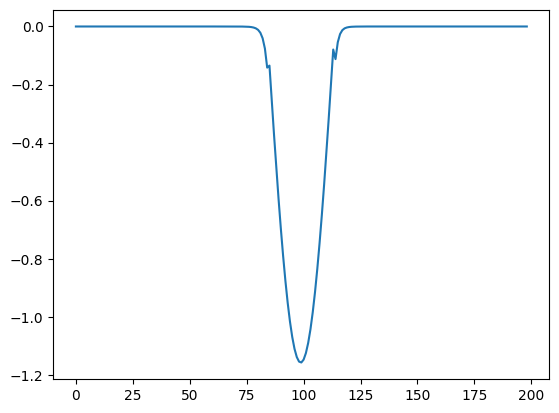

Epoch 4249:
  β² prediction ≈ [114.31502  307.55856  214.60101   99.3195    99.447464  71.29191
 106.96646  188.02892   27.874472 139.8766   110.89517  178.75
 199.64482   76.0536    70.076355  79.5058   124.73731   66.14782
  68.64054  109.38093   45.015972 186.61545   74.82904   46.683456
 116.82362  298.66754   49.268776 288.8204    51.524853 139.38905
  99.59523  358.29715  292.6656   309.90546  206.87938   60.53736
  43.24383   52.447166 223.51741   65.66873  119.38069   62.66956
  21.179132 193.58644  144.989    105.642006  93.590965 103.77877
  26.406055 121.14529  154.64127   94.50803   68.931725 102.99843
 276.54013  114.77318  209.40562  366.9128   134.69133   43.95963
 172.24446  110.46154  249.69444   90.54703 ]
  β² max ≈ [116.64747  309.98785  218.74034  104.31079  104.46617   73.28237
 111.72533  191.24767   31.748745 143.49307  115.37116  182.90768
 202.92546   79.29184   73.78151   81.40353  129.9351    67.94183
  72.011375 111.41625   49.72307  192.25104   76.74819   

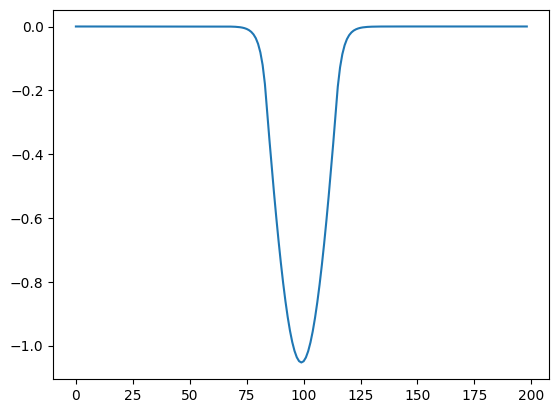

Epoch 5249:
  β² prediction ≈ [180.92189   96.54667  243.36995  136.16011  173.91266  146.2004
 276.11978   50.961998  38.338867 152.09308  388.92822   74.15947
 162.3784   112.1542    44.23724  103.2149    44.42825  106.25424
 326.2279   196.31456   60.928356 112.225426 131.33983   39.417324
  98.63561  147.7024   137.97874  105.42585  275.60822  132.96846
 124.32518  151.32361   96.43648  123.4875    83.23837  355.13452
  98.18689  137.89882  178.87529   58.38368   71.78665  262.90646
  39.5337   312.11362   53.26272  152.3591   303.36533  102.03675
 223.81915   32.692635 211.08797  247.81905  216.28358  141.92046
 325.19562  163.32358  199.52695  161.98726  122.4885   135.93893
  42.10229  187.36957  171.03564  254.75168 ]
  β² max ≈ [183.38177  101.09424  245.6048   138.75352  177.21259  150.89381
 282.1394    53.419025  39.908447 155.48778  394.07208   78.751724
 166.31895  114.79309   45.92296  107.08473   48.702885 109.21036
 330.16522  200.53647   63.261883 114.76035  137.19849

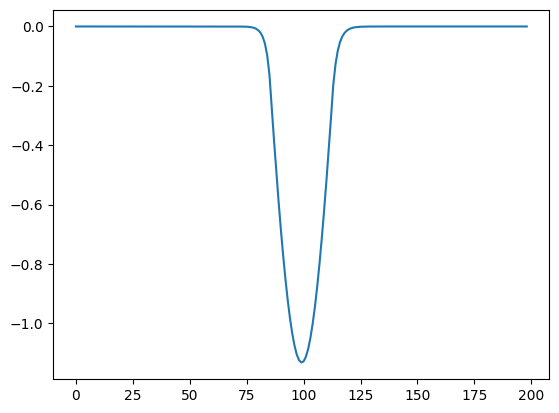

Epoch 6249:
  β² prediction ≈ [290.98532  193.36255  136.35507  147.8159   132.37576   83.27782
 163.28761  107.92409   92.65777  315.56006  135.40211  364.6165
 419.1869   110.05647  106.6127   171.02594  146.5841   122.11758
 127.72906  114.45507   89.4564    50.932213  38.747704 178.79807
  45.54992  185.49841  117.8316    26.61838   63.33495  144.36452
 130.98096   94.34302  132.86182  454.56906   61.170315 112.884834
 114.930664  77.39046   71.18975  272.26688   40.850296 130.81168
  63.501785 121.02046   96.774124 150.763     41.68516   62.151707
 158.29382   37.25101   49.781033 190.28366  248.73643  188.99825
 110.45481  269.3478    85.99253  184.5429    74.011955  47.98607
 243.56255  102.973366 109.09996  199.34114 ]
  β² max ≈ [298.00052  197.69781  139.60347  151.39577  140.66766   87.43359
 168.96962  110.28865   97.45033  317.83325  138.62576  371.81366
 423.7707   112.17116  108.64236  173.79153  150.06317  127.49563
 129.93837  117.49582   92.99763   54.668335  40.01695

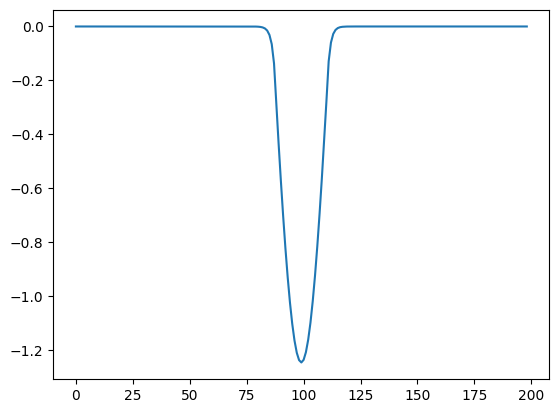

Epoch 7249:
  β² prediction ≈ [ 46.87234  128.4721    55.248005 322.46317  280.97556  102.60132
 344.20193   68.6531    51.417103 105.19161   47.69278   62.112747
  75.44581  140.63045  218.64629  264.0855   149.91434  234.32045
 136.94116   90.91327   72.54089   50.782455 119.07394  195.83748
 146.65654   47.11993   37.76577   54.58588  263.54965   80.47326
 176.61829  345.14407   20.033426  94.34445  182.17517  111.08417
  99.19709   44.343822  90.424194 122.42196  137.03506  109.40675
 216.72409  226.19229  119.72605  110.74732  164.2961   157.96098
 114.29696  180.93858  341.71768  121.61497   67.92674   54.4382
  38.925865 268.56366  394.48178  172.27873  293.05948  141.94652
  52.39347   94.5932    52.10366   23.796913]
  β² max ≈ [ 50.58675  132.51593   58.746452 326.41718  283.45966  104.83581
 347.69034   70.11904   54.4613   106.76824   49.10823   67.0439
  80.75771  143.09026  225.76591  266.5533   156.96045  237.37325
 139.98743   94.09943   80.00918   52.275944 122.11828  

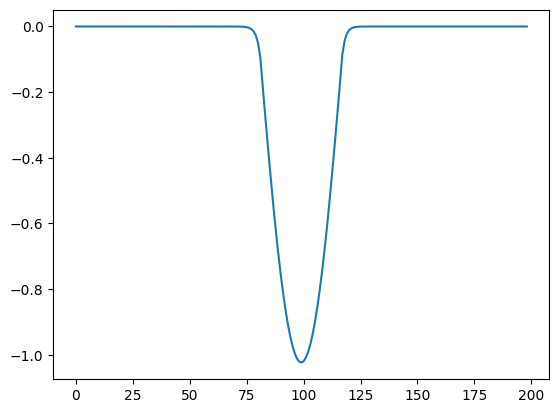

Epoch 8249:
  β² prediction ≈ [ 95.63736  335.73865  112.978004  70.86089  215.90683  301.88495
 412.5982    34.978374 334.4949   246.28082  125.59091  325.74942
 107.70932  207.23402   87.642654  84.41835   55.6551   177.4719
 120.93593   80.65945  153.67104   53.969643 198.5057    75.15141
 219.34067   54.085537 126.556046  71.33402  134.25076  152.08295
 129.27583  119.16618  114.61669   99.03513   59.866653  81.09834
  44.074978 100.135475  49.64286   78.59188   45.099842 211.6329
 129.50809   85.50443  261.6911   178.01346  177.85162   95.55034
 127.8981    49.407272 210.69472  241.58563  123.409515 172.6588
 264.1112   146.05939  114.4852    76.121544  89.23813  147.80334
 290.3137   117.05702   39.773544 146.60452 ]
  β² max ≈ [ 97.51945  342.9413   115.716446  73.188194 220.17635  305.38034
 415.40115   36.415104 337.59744  252.44214  130.48097  331.80658
 109.970795 211.45863   91.34665   91.06631   58.6912   184.45493
 124.84701   85.76679  156.58829   56.90454  203.83849   8

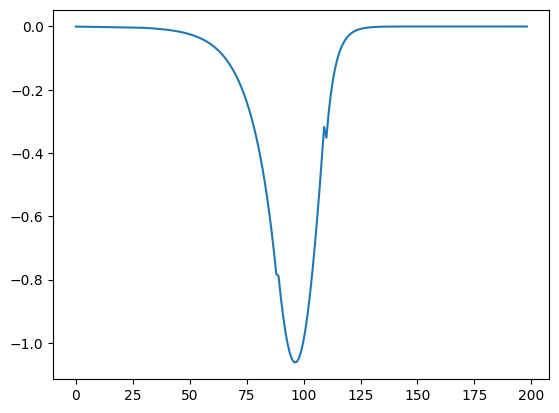

Epoch 9249:
  β² prediction ≈ [193.20609  110.05645   51.76488  104.878525 159.41452  103.9312
 130.09613  178.80275   27.202255 115.96137   69.291954 131.40253
 364.73306   87.930756 105.87261  105.34295   37.80443  125.79658
  64.548    328.34048  134.61263  122.530815  70.38349   52.64323
  50.786118  53.63379   66.93837  136.2318   237.80737   96.60388
  76.09071  132.30775   81.45254  165.34793  234.60143   98.77125
  54.996487 131.12198  223.28136  129.904    156.98448   39.537445
 107.43252  164.49081  188.79141  295.2637   104.342384  55.38281
 129.44113  205.35268   29.6671   278.66638  127.99869  311.5715
 103.596886  43.275066  61.866417 158.84465  163.53638   40.53276
 170.9942   135.39114  113.37499   90.140854]
  β² max ≈ [196.17207  113.210365  55.503693 109.79842  162.05815  107.86562
 132.20169  182.9725    31.316664 118.018936  74.34759  136.32742
 367.86258   89.786    111.01646  107.7899    40.388985 129.40329
  66.55468  335.32837  137.78156  124.51544   74.03771  

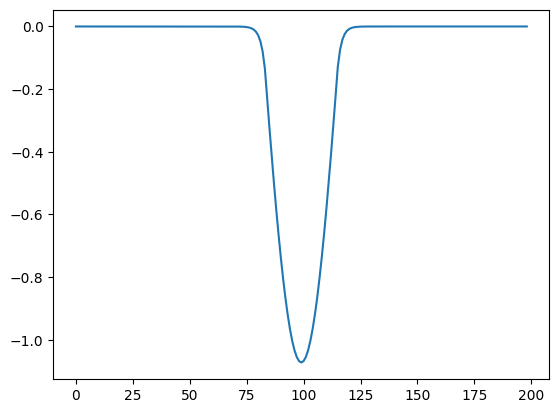

In [9]:
train_losses = []
val_losses = []
eigval_errors = []
field_errors = []
torch.manual_seed(42)
val_ds = SlabWaveguideDataset(dx = 1/20, n_dataset=1000, x_range=(-5.0, 5.0), device=device)
val_loader = DataLoader(val_ds, batch_size=1000, shuffle=True)
for datasetsize in [500, 1000, 5000, 10000, None]:
    if datasetsize is None:
        dataset = SlabWaveguideDataset(n_dataset = 64, stochastic=True, x_range=(-5.0, 5.0), device=device)
        shuffle = False
    else:
        dataset = SlabWaveguideDataset(dx = 1/20, n_dataset=datasetsize, x_range=(-5.0, 5.0), device=device)
        shuffle = True
    loader = DataLoader(dataset, batch_size=64, shuffle=shuffle)
    # Setup
    model = PINO1D(4, 1, 64, 32, 4).to(device)
    optimizer = soap.SOAP(model.parameters())
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5000, 8500], gamma=1e-1)
    model, betas_avg, analytical_EIs, train_loss_history, val_loss_history = train(loader, val_loader, model, optimizer, scheduler, epochs=10001, load=False, save=True)
    train_losses.append(train_loss_history)
    val_losses.append(val_loss_history)
    errors = evaluate_model_errors(model, val_ds, device)
    eigval_errors.append(errors["eigen_error_pino"])
    field_errors.append(errors["field_error_pino"])

In [11]:
# torch.save(train_losses, 'train_losses.pt')
# torch.save(val_losses, 'val_losses.pt')
# torch.save(eigval_errors, 'eigval_errors.pt')
# torch.save(field_errors, 'field_errors.pt')

In [3]:
# train_losses = torch.load('train_losses.pt')
# val_losses = torch.load('val_losses.pt')
# eigval_errors = torch.load('eigval_errors.pt')
# field_errors = torch.load('field_errors.pt')

In [9]:
print('dataset sizes: 500, 1000, 5000, 10000, stochastic')
print('eigenvalue error: ',[round(eigerror.item(), 5) for eigerror in eigval_errors])
print('field errors: ', [round(fielderror.item(), 5) for fielderror in field_errors])

dataset sizes: 500, 1000, 5000, 10000, stochastic
eigenvalue error:  [0.0007, 0.00063, 0.00055, 0.00056, 0.00054]
field errors:  [2.11483, 1.80427, 1.61651, 1.6963, 1.54919]


In [ ]:
# Compute running average
def running_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


for i in range(len(train_losses)):
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses[i], color='lightblue')
    smoothed_loss = running_average(train_losses[i])
    plt.plot(smoothed_loss, label='training Loss', color='blue', linewidth=2)
    plt.plot(torch.arange(250, 10001, 250), val_losses[i], label=f'Validation Loss', linewidth=3, color='#FF69B4', marker='o')
    
    plt.yscale('log')
    plt.ylim([9e-6, 1e2])
    plt.xlabel('Epoch', fontsize=12)    
    
    plt.legend(fontsize=10)
    plt.grid(True, which="both", ls="--", lw=0.5)   
    plt.tight_layout()
    
    plt.show()

In [52]:
torch.manual_seed(42)
val_ds = SlabWaveguideDataset(dx = 1/20, n_dataset=1000, x_range=(-5.0, 5.0), device=device)

In [53]:
errors = evaluate_model_errors(model, val_ds, device)

In [54]:
for key, value in errors.items():
    if not 'errors' in key:
        print(f"{key}: {value if isinstance(value, float) else 0:.4e}")

field_error_pino: 1.5492e+00
field_error_fd: 1.4498e+00
eigen_error_pino: 5.4408e-04
eigen_error_fd: 5.4537e-04
field_error_pino_std: 1.6557e+00
field_error_fd_std: 1.5517e+00
eigen_error_pino_std: 5.7071e-04
eigen_error_fd_std: 5.5578e-04
field_error_pino_ci95: 1.0262e-01
field_error_fd_ci95: 9.6173e-02
eigen_error_pino_ci95: 3.5373e-05
eigen_error_fd_ci95: 3.4448e-05
